In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.utils import shuffle

In [15]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.metrics import precision_score, recall_score, classification_report
import xgboost
import sklearn
from scipy.stats import pearsonr

In [16]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Data Preprocessing

In [5]:
unbalanced_A = pd.read_csv("/content/drive/MyDrive/Processed/cleansed_dataset_own.csv", index_col=0)

unbalanced_A.shape

(21785, 24788)

In [6]:
unbalanced_A.iloc[:, 1:] = unbalanced_A.iloc[:, 1:].round(3)

print(unbalanced_A.shape)
print(unbalanced_A.head())

(21785, 24788)
                            CellType  RP11-34P13.7  RP11-34P13.8  FO538757.2  \
AAACCTGAGAGATGAG-1  Epithelial cells           0.0           0.0       0.321   
TGAGGGAGTCATATGC-1            Others           0.0           0.0       0.000   
CTAATGGTCCCAGGTG-1       Fibroblasts           0.0           0.0       0.000   
CTAGAGTTCTGGCGAC-1  Epithelial cells           0.0           0.0       0.000   
CTCGGAGGTGGTGTAG-1  Epithelial cells           0.0           0.0       0.000   

                    AP006222.2  RP4-669L17.10  RP5-857K21.4  RP5-857K21.2  \
AAACCTGAGAGATGAG-1       0.563            0.0           0.0           0.0   
TGAGGGAGTCATATGC-1       0.000            0.0           0.0           0.0   
CTAATGGTCCCAGGTG-1       0.000            0.0           0.0           0.0   
CTAGAGTTCTGGCGAC-1       0.685            0.0           0.0           0.0   
CTCGGAGGTGGTGTAG-1       0.000            0.0           0.0           0.0   

                    RP11-206L10.9  FAM87B

In [7]:
unbalanced_A['cells'] = unbalanced_A['CellType']
unbalanced_A['CellType'] = unbalanced_A['CellType'].apply(
    lambda x: 'Epithelial' if x == 'Epithelial cells' else 'non-Epithelial'
)

print(unbalanced_A['CellType'].value_counts())
print(unbalanced_A.head())

CellType
Epithelial        15425
non-Epithelial     6360
Name: count, dtype: int64
                          CellType  RP11-34P13.7  RP11-34P13.8  FO538757.2  \
AAACCTGAGAGATGAG-1      Epithelial           0.0           0.0       0.321   
TGAGGGAGTCATATGC-1  non-Epithelial           0.0           0.0       0.000   
CTAATGGTCCCAGGTG-1  non-Epithelial           0.0           0.0       0.000   
CTAGAGTTCTGGCGAC-1      Epithelial           0.0           0.0       0.000   
CTCGGAGGTGGTGTAG-1      Epithelial           0.0           0.0       0.000   

                    AP006222.2  RP4-669L17.10  RP5-857K21.4  RP5-857K21.2  \
AAACCTGAGAGATGAG-1       0.563            0.0           0.0           0.0   
TGAGGGAGTCATATGC-1       0.000            0.0           0.0           0.0   
CTAATGGTCCCAGGTG-1       0.000            0.0           0.0           0.0   
CTAGAGTTCTGGCGAC-1       0.685            0.0           0.0           0.0   
CTCGGAGGTGGTGTAG-1       0.000            0.0           0.0    

In [8]:
unbalanced_B = pd.read_csv("/content/drive/MyDrive/Processed/normalized_dataset_new.csv", index_col=0)

unbalanced_B.shape

(28855, 25565)

In [9]:
unbalanced_B.iloc[:, 1:] = unbalanced_B.iloc[:, 1:].round(3)

print(unbalanced_B.shape)
print(unbalanced_B.head())

(28855, 25565)
                                   cells  RP11-34P13.7  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Others           0.0         0.0   

                                  AP006222.2  RP4-669L17.10  RP5-857K21.3  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1         0.0            0.0           0.0   

                                  RP5-857K21.4  RP11-206L10.3  RP11-206L10.5  \
SCG-PCA4-T-HG_AACTCTT

In [10]:
unbalanced_B['CellType'] = unbalanced_B['cells'].apply(
    lambda x: 'Epithelial' if x == 'Epithelial cells' else 'non-Epithelial'
)

print(unbalanced_B['CellType'].value_counts())
print(unbalanced_B.head())

CellType
non-Epithelial    27245
Epithelial         1610
Name: count, dtype: int64
                                   cells  RP11-34P13.7  AL627309.1  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1  Others           0.0         0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1  Others           0.0         0.0   

                                  AP006222.2  RP4-669L17.10  RP5-857K21.3  \
SCG-PCA4-T-HG_AACTCTTGTCACACGC-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AACTGGTTCTTGCAAG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_AAGGCAGCATACAGCT-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACCGTAATCTAACTGG-1         0.0            0.0           0.0   
SCG-PCA4-T-HG_ACGATACAGGAGTCTG-1         0.0            0.0           0.0   

                                 

In [15]:
common_columns = unbalanced_A.columns.intersection(unbalanced_B.columns)

reduced_A = unbalanced_A[common_columns].copy()
reduced_B = unbalanced_B[common_columns].copy()

reduced_A.head()

,CellType,RP11-34P13.7,AP006222.2,RP4-669L17.10,RP5-857K21.4,RP11-206L10.9,FAM87B,LINC00115,FAM41C,RP11-54O7.1,...,YBEY,C21orf58,PCNT,DIP2A,S100B,PRMT2,AC011043.1,AL592183.1,AL354822.1,cells
AAACCTGAGAGATGAG-1,Epithelial,0.0,0.563,0.0,0.0,0.0,0.0,0.0,0.0,0.321,...,0.563,0.0,0.000,0.321,0.0,0.000,0.0,0.0,0.0,Epithelial cells
TGAGGGAGTCATATGC-1,non-Epithelial,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,...,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,Others
CTAATGGTCCCAGGTG-1,non-Epithelial,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,...,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,Fibroblasts
CTAGAGTTCTGGCGAC-1,Epithelial,0.0,0.685,0.0,0.0,0.0,0.0,0.0,0.0,0.000,...,0.504,0.0,0.283,0.000,0.0,0.000,0.0,0.0,0.0,Epithelial cells
CTCGGAGGTGGTGTAG-1,Epithelial,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,...,0.329,0.0,0.000,0.000,0.0,0.329,0.0,0.0,0.0,Epithelial cells


In [29]:
unbalanced_A.shape

(21785, 24789)

In [27]:
unbalanced_B.shape

(28855, 25566)

In [28]:
output_folder = "/content/drive/MyDrive/Processed/final"
unbalanced_A.to_csv(f"{output_folder}/unbalanced_A.csv", index=False)
unbalanced_B.to_csv(f"{output_folder}/unbalanced_B.csv", index=False)

Balanced

In [34]:
epi_cells = reduced_A[reduced_A['CellType'] == 'Epithelial']
non_epi_cells = reduced_A[reduced_A['CellType'] != 'Epithelial']

non_epi_duplicated = pd.concat([non_epi_cells] * 2, ignore_index=True)

balanced_A = pd.concat([epi_cells, non_epi_duplicated], ignore_index=True)

balanced_A = balanced_A.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Balanced Dataset A Shape:", balanced_A.shape)
print(balanced_A['CellType'].value_counts())

✅ Balanced Dataset A Shape: (28145, 21821)
CellType
Epithelial        15425
non-Epithelial    12720
Name: count, dtype: int64


In [45]:
balanced_A.to_csv(f"{output_folder}/balanced_A.csv", index=False)

In [40]:
epi_cells_B = reduced_B[reduced_B['CellType'] == 'Epithelial']
non_epi_cells_B = reduced_B[reduced_B['CellType'] != 'Epithelial']

epi_repeated = pd.concat([epi_cells_B] * 3, ignore_index=True)

non_epi_downsampled = non_epi_cells_B.sample(
    frac=0.2, random_state=42)

balanced_B = pd.concat([epi_repeated, non_epi_downsampled], ignore_index=True)

balanced_B = balanced_B.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Balanced Dataset B Shape:", balanced_B.shape)
print(balanced_B['CellType'].value_counts())

✅ Balanced Dataset B Shape: (10279, 21821)
CellType
non-Epithelial    5449
Epithelial        4830
Name: count, dtype: int64


In [43]:
balanced_B.to_csv(f"{output_folder}/balanced_B.csv", index=False)

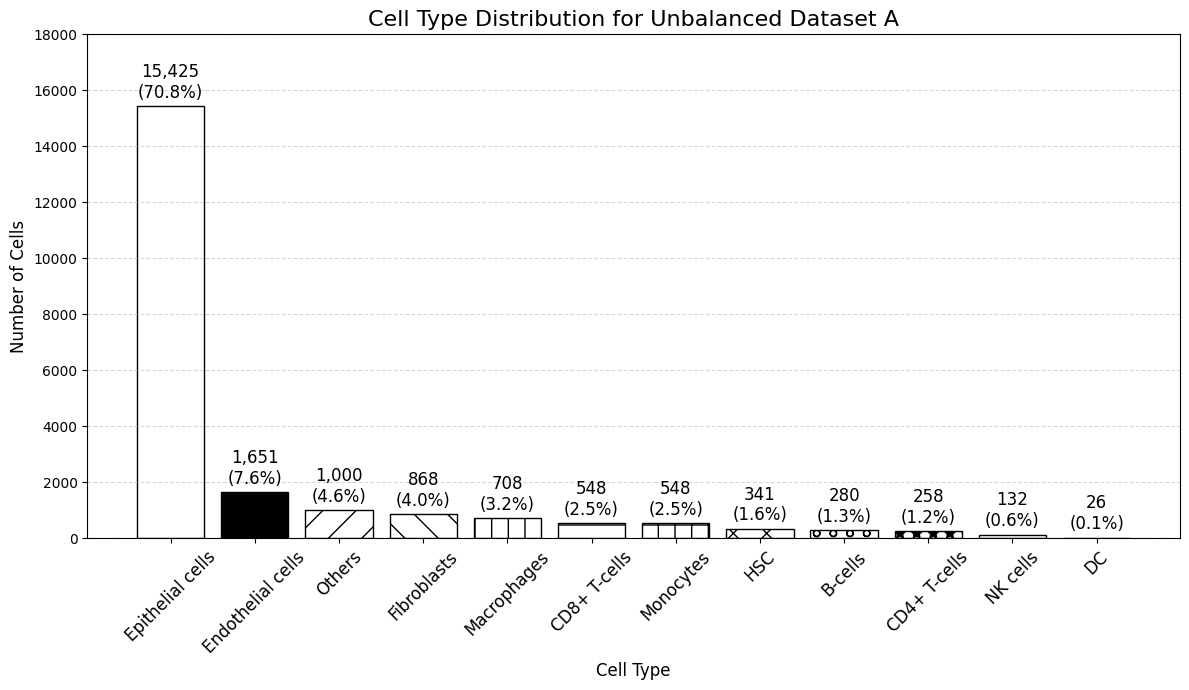

In [57]:
cell_type_counts = reduced_A['cells'].value_counts().sort_values(ascending=False)
total_cells = cell_type_counts.sum()
cell_types = cell_type_counts.index.tolist()

hatch_patterns = ['/', '\\', '|', '-', '+', 'x', 'o', '*', '.', 'O']

visual_map = {}
for i, cell in enumerate(cell_types):
    if i == 0:
        visual_map[cell] = {'color': 'white', 'hatch': ''}
    elif i == 1:
        visual_map[cell] = {'color': 'black', 'hatch': ''}
    else:
        visual_map[cell] = {'color': 'white', 'hatch': hatch_patterns[(i - 2) % len(hatch_patterns)]}

fig, ax = plt.subplots(figsize=(12, 7))
bars = []
for i, cell in enumerate(cell_type_counts.index):
    bar = ax.bar(
        cell,
        cell_type_counts[cell],
        color=visual_map[cell]['color'],
        edgecolor='black',
        hatch=visual_map[cell]['hatch']
    )
    bars.append(bar)

for i, (cell_type, count) in enumerate(cell_type_counts.items()):
    percentage = (count / total_cells) * 100
    ax.text(
        i,
        count + max(cell_type_counts) * 0.01,
        f"{count:,}\n({percentage:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('Cell Type Distribution for Unbalanced Dataset A', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.xticks(rotation=45, fontsize=12, ha='center')
plt.tight_layout()
plt.ylim(0, 18000)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [58]:
cell_type_counts_A = reduced_A['cells'].value_counts().sort_values(ascending=False)
cell_types_A = cell_type_counts_A.index.tolist()

hatch_patterns = ['', '', '/', '\\', '|', '-', '+', 'x', 'o', '*', '.', 'O']

colors = ['white', 'black'] + ['white'] * (len(cell_types_A) - 2)

cell_type_visual_map = {}
for i, cell_type in enumerate(cell_types_A):
    hatch = hatch_patterns[i % len(hatch_patterns)]
    color = colors[i % len(colors)]
    cell_type_visual_map[cell_type] = {'hatch': hatch, 'color': color}

print("Generated Visual Map:")
for k, v in cell_type_visual_map.items():
    print(f"{k}: {v}")


Generated Visual Map:
Epithelial cells: {'hatch': '', 'color': 'white'}
Endothelial cells: {'hatch': '', 'color': 'black'}
Others: {'hatch': '/', 'color': 'white'}
Fibroblasts: {'hatch': '\\', 'color': 'white'}
Macrophages: {'hatch': '|', 'color': 'white'}
CD8+ T-cells: {'hatch': '-', 'color': 'white'}
Monocytes: {'hatch': '+', 'color': 'white'}
HSC: {'hatch': 'x', 'color': 'white'}
B-cells: {'hatch': 'o', 'color': 'white'}
CD4+ T-cells: {'hatch': '*', 'color': 'white'}
NK cells: {'hatch': '.', 'color': 'white'}
DC: {'hatch': 'O', 'color': 'white'}


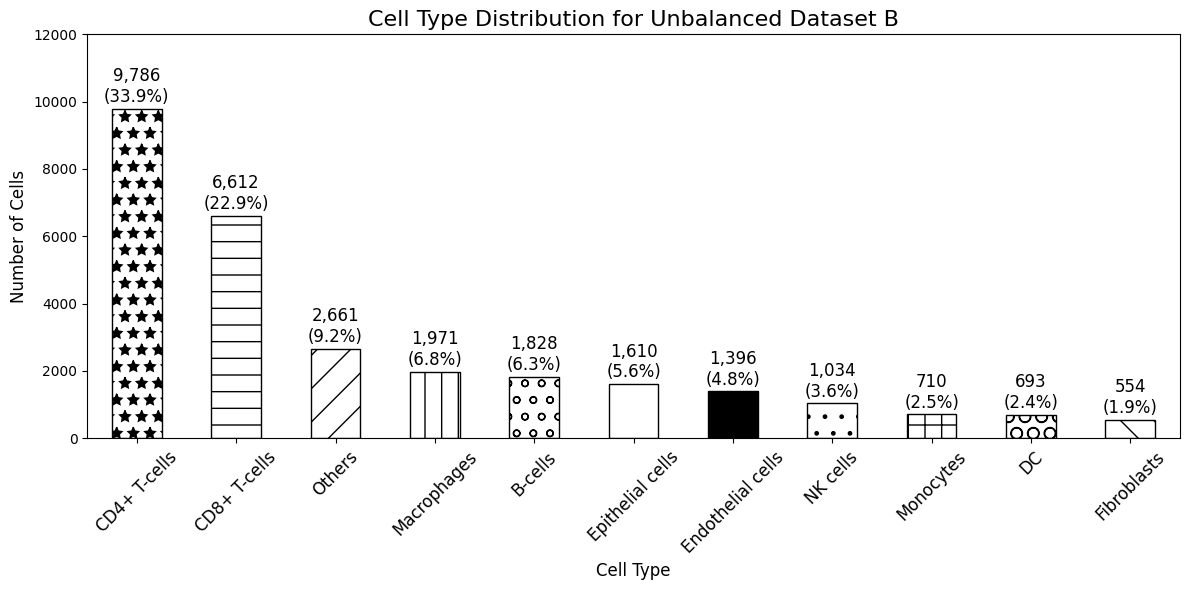

In [60]:
cell_type_counts_B = reduced_B['cells'].value_counts().sort_values(ascending=False)

bar_colors_B = [cell_type_visual_map.get(cell, {'color': 'white'})['color'] for cell in cell_type_counts_B.index]
bar_hatches_B = [cell_type_visual_map.get(cell, {'hatch': ''})['hatch'] for cell in cell_type_counts_B.index]

plt.figure(figsize=(12, 6))
ax = cell_type_counts_B.plot(kind='bar', color=bar_colors_B, edgecolor='black', hatch=bar_hatches_B)

plt.title('Cell Type Distribution for Unbalanced Dataset B', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)

total = cell_type_counts_B.sum()
for i, count in enumerate(cell_type_counts_B):
    percentage = count / total * 100
    label = f"{count:,}\n({percentage:.1f}%)"
    ax.text(i, count + 200, label, ha='center', fontsize=12)

plt.xticks(rotation=45, fontsize=12, ha='center')
plt.ylim(0, 12000)
plt.tight_layout()
plt.show()


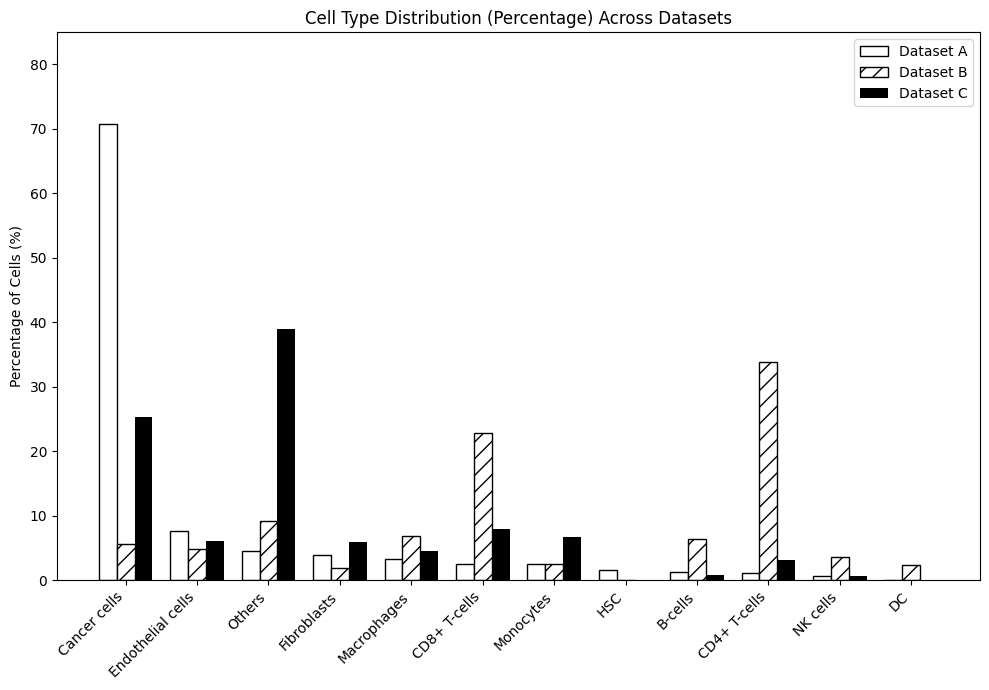

In [9]:
import matplotlib.pyplot as plt
import numpy as np

counts_A = {
    'Epithelial cells': 15425, 'Endothelial cells': 1651, 'Others': 1000, 'Fibroblasts': 868,
    'Macrophages': 708, 'CD8+ T-cells': 548, 'Monocytes': 548, 'HSC': 341, 'B-cells': 280,
    'CD4+ T-cells': 258, 'NK cells': 132, 'DC': 26
}

counts_B = {
    'CD4+ T-cells': 9786, 'CD8+ T-cells': 6612, 'Others': 2661, 'Macrophages': 1971,
    'B-cells': 1828, 'Epithelial cells': 1610, 'Endothelial cells': 1396, 'NK cells': 1034,
    'Monocytes': 710, 'DC': 693, 'Fibroblasts': 554
}

counts_C = {
    'Others': 8475, 'Epithelial cells': 5494, 'CD8+ T-cells': 1713, 'Monocytes': 1472,
    'Endothelial cells': 1332, 'Fibroblasts': 1276, 'Macrophages': 981,
    'CD4+ T-cells': 688, 'B-cells': 178, 'NK cells': 134
}

def rename_keys(d):
    return {('Cancer cells' if k == 'Epithelial cells' else k): v for k, v in d.items()}

counts_A = rename_keys(counts_A)
counts_B = rename_keys(counts_B)
counts_C = rename_keys(counts_C)

labels = list(counts_A.keys())

total_A = sum(counts_A.values())
total_B = sum(counts_B.values())
total_C = sum(counts_C.values())

values_A = [counts_A.get(label, 0) / total_A * 100 for label in labels]
values_B = [counts_B.get(label, 0) / total_B * 100 for label in labels]
values_C = [counts_C.get(label, 0) / total_C * 100 for label in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 7))

ax.bar(x - width, values_A, width, label='Dataset A', color='white', edgecolor='black')
ax.bar(x, values_B, width, label='Dataset B', color='white', edgecolor='black', hatch='//')
ax.bar(x + width, values_C, width, label='Dataset C', color='black')

ax.set_ylabel('Percentage of Cells (%)')
ax.set_title('Cell Type Distribution (Percentage) Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim(0, max(values_A + values_B + values_C) * 1.2)
ax.legend()

plt.tight_layout()
plt.show()


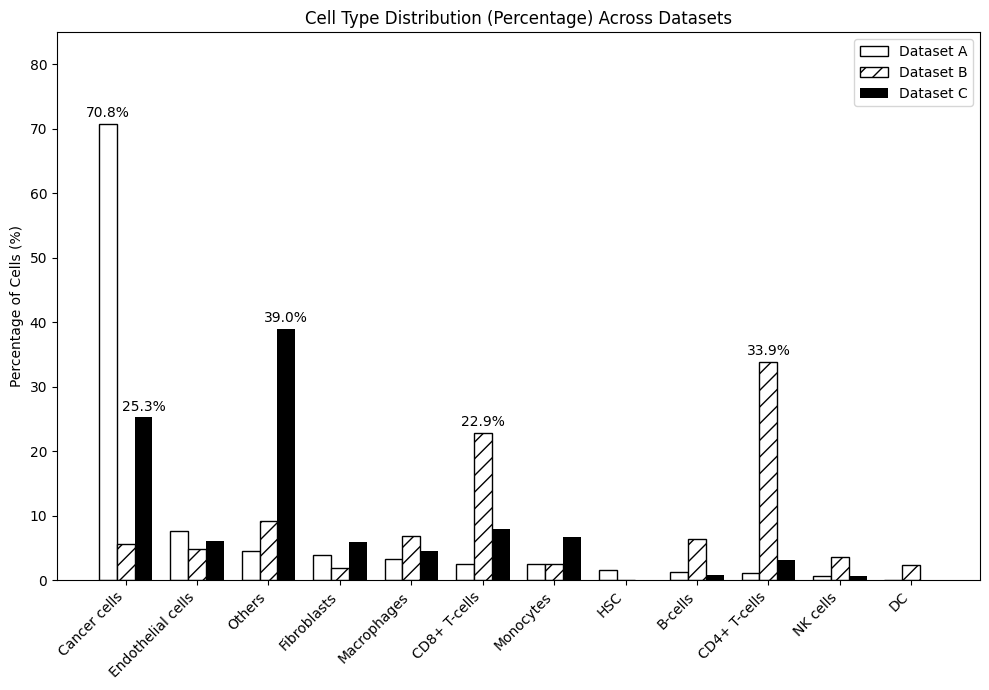

In [14]:
import matplotlib.pyplot as plt
import numpy as np

counts_A = {
    'Epithelial cells': 15425, 'Endothelial cells': 1651, 'Others': 1000, 'Fibroblasts': 868,
    'Macrophages': 708, 'CD8+ T-cells': 548, 'Monocytes': 548, 'HSC': 341, 'B-cells': 280,
    'CD4+ T-cells': 258, 'NK cells': 132, 'DC': 26
}

counts_B = {
    'CD4+ T-cells': 9786, 'CD8+ T-cells': 6612, 'Others': 2661, 'Macrophages': 1971,
    'B-cells': 1828, 'Epithelial cells': 1610, 'Endothelial cells': 1396, 'NK cells': 1034,
    'Monocytes': 710, 'DC': 693, 'Fibroblasts': 554
}

counts_C = {
    'Others': 8475, 'Epithelial cells': 5494, 'CD8+ T-cells': 1713, 'Monocytes': 1472,
    'Endothelial cells': 1332, 'Fibroblasts': 1276, 'Macrophages': 981,
    'CD4+ T-cells': 688, 'B-cells': 178, 'NK cells': 134
}

def rename_keys(d):
    return {('Cancer cells' if k == 'Epithelial cells' else k): v for k, v in d.items()}

counts_A = rename_keys(counts_A)
counts_B = rename_keys(counts_B)
counts_C = rename_keys(counts_C)

labels = list(counts_A.keys())

total_A = sum(counts_A.values())
total_B = sum(counts_B.values())
total_C = sum(counts_C.values())

values_A = [counts_A.get(label, 0) / total_A * 100 for label in labels]
values_B = [counts_B.get(label, 0) / total_B * 100 for label in labels]
values_C = [counts_C.get(label, 0) / total_C * 100 for label in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 7))

bars_A = ax.bar(x - width, values_A, width, label='Dataset A', color='white', edgecolor='black')
bars_B = ax.bar(x, values_B, width, label='Dataset B', color='white', edgecolor='black', hatch='//')
bars_C = ax.bar(x + width, values_C, width, label='Dataset C', color='black')

def add_labels(bars, values):
    for bar, value in zip(bars, values):
        if value > 20:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}%',
                    ha='center', fontsize=10)

add_labels(bars_A, values_A)
add_labels(bars_B, values_B)
add_labels(bars_C, values_C)

ax.set_ylabel('Percentage of Cells (%)')
ax.set_title('Cell Type Distribution (Percentage) Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylim(0, max(values_A + values_B + values_C) * 1.2)
ax.legend()

plt.tight_layout()
plt.show()


Cancer Cell Cluster

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from numpy.linalg import norm
import math

In [5]:
reduced_A = pd.read_csv("/content/drive/MyDrive/Processed/final/reduced_unbalanced_A.csv")

reduced_A.shape

(21785, 21821)

In [6]:
reduced_B = pd.read_csv("/content/drive/MyDrive/Processed/final/reduced_unbalanced_B.csv")

reduced_B.shape

(28855, 21821)

In [8]:
cancer_A = reduced_A[reduced_A["CellType"] == "Epithelial"].copy()
cancer_B = reduced_B[reduced_B["CellType"] == "Epithelial"].copy()

X_A = cancer_A.drop(columns=["CellType", "cells"]).values
X_B = cancer_B.drop(columns=["CellType", "cells"]).values

mean_A = X_A.mean(axis=0)
std_A = X_A.std(axis=0)

mean_B = X_B.mean(axis=0)
std_B = X_B.std(axis=0)

pearson_r, _ = pearsonr(mean_A, mean_B)

cos_theta = np.dot(mean_A, mean_B) / (norm(mean_A) * norm(mean_B))
cos_theta = np.clip(cos_theta, -1.0, 1.0)

mean_diff = np.abs(mean_A - mean_B)
avg_std = (std_A + std_B) / 2
relative_diff = mean_diff / (avg_std + 1e-8)
mean_relative_diff = np.mean(relative_diff)

print("\n🔬 Mean Vector Comparison Between Cancer Cells in A and B:")
print(f"🔹 Pearson Correlation (mean_A vs mean_B): {pearson_r:.4f}")
print(f"🔹 Cosine Similarity Between Mean Vectors: {cos_theta:.2f}")
print(f"🔹 Avg. |Mean Difference| / Std: {mean_relative_diff:.4f}")


🔬 Mean Vector Comparison Between Cancer Cells in A and B:
🔹 Pearson Correlation (mean_A vs mean_B): 0.7448
🔹 Cosine Similarity Between Mean Vectors: 0.77
🔹 Avg. |Mean Difference| / Std: 0.2485


In [9]:
cell_types_A = set(reduced_A['cells'].unique())
cell_types_B = set(reduced_B['cells'].unique())
common_cell_types = cell_types_A.intersection(cell_types_B)

results = []

for cell_type in common_cell_types:
    subset_A = reduced_A[reduced_A['cells'] == cell_type].drop(columns=["CellType", "cells"])
    subset_B = reduced_B[reduced_B['cells'] == cell_type].drop(columns=["CellType", "cells"])

    X_A = subset_A.values
    X_B = subset_B.values

    mean_A = X_A.mean(axis=0)
    std_A = X_A.std(axis=0)

    mean_B = X_B.mean(axis=0)
    std_B = X_B.std(axis=0)

    pearson_r, _ = pearsonr(mean_A, mean_B)

    cos_theta = np.dot(mean_A, mean_B) / (norm(mean_A) * norm(mean_B))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    mean_diff = np.abs(mean_A - mean_B)
    avg_std = (std_A + std_B) / 2
    relative_diff = mean_diff / (avg_std + 1e-8)
    mean_relative_diff = np.mean(relative_diff)

    results.append({
    "CellType": "Cancer cells" if cell_type == "Epithelial cells" else cell_type,
    "PearsonCorrelation": pearson_r,
    "Cosine": cos_theta,
    "MeanDifference/Std": mean_relative_diff
    })

In [11]:
results_df = pd.DataFrame(results)

results_df

,CellType,PearsonCorrelation,Cosine,MeanDifference/Std
0,Endothelial cells,0.713402,0.751080,0.274993
1,DC,0.707562,0.744517,0.302151
2,NK cells,0.775868,0.801453,0.292695
3,Macrophages,0.689366,0.730032,0.289213
4,Cancer cells,0.744838,0.767589,0.248517
5,CD4+ T-cells,0.840177,0.856890,0.280929
6,Fibroblasts,0.666479,0.713857,0.286178
7,B-cells,0.828113,0.844234,0.254608
8,Monocytes,0.689812,0.731017,0.303529
9,Others,0.794711,0.816323,0.269175


In [14]:
cancer_A = reduced_A[reduced_A["cells"] == "Epithelial cells"]

X_cancer = cancer_A.drop(columns=["cells", "CellType"]).values
mean_cancer = X_cancer.mean(axis=0)
std_cancer = X_cancer.std(axis=0)

cell_types_A = set(reduced_A['cells'].unique())

results = []
for cell_type in cell_types_A:
    if cell_type == "Epithelial cells":
        continue

    other_A = reduced_A[reduced_A["cells"] == cell_type]

    X_other = other_A.drop(columns=["cells", "CellType"]).values
    mean_other = X_other.mean(axis=0)
    std_other = X_other.std(axis=0)

    pearson_r, _ = pearsonr(mean_cancer, mean_other)

    cos_theta = np.dot(mean_cancer, mean_other) / (norm(mean_cancer) * norm(mean_other))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    mean_diff = np.abs(mean_cancer - mean_other)
    avg_std = (std_cancer + std_other) / 2
    relative_diff = mean_diff / (avg_std + 1e-8)
    mean_relative_diff = np.mean(relative_diff)

    results.append({
        "Other_CellType": cell_type,
        "PearsonCorrelation": pearson_r,
        "Cosine": cos_theta,
        "MeanDifference/Std": mean_relative_diff
    })

In [15]:
results_df = pd.DataFrame(results)

results_df

,Other_CellType,PearsonCorrelation,Cosine,MeanDifference/Std
0,Endothelial cells,0.979794,0.981990,0.071442
1,DC,0.958197,0.962746,0.167665
2,NK cells,0.953033,0.957971,0.124126
3,Macrophages,0.990913,0.991897,0.058401
4,Fibroblasts,0.976227,0.978784,0.079065
5,CD4+ T-cells,0.946983,0.952509,0.120813
6,B-cells,0.930542,0.937373,0.135780
7,Monocytes,0.983929,0.985672,0.073266
8,HSC,0.984245,0.985796,0.079072
9,Others,0.978130,0.980509,0.077317


In [16]:
cancer_B = reduced_B[reduced_B["cells"] == "Epithelial cells"]

X_cancer = cancer_B.drop(columns=["cells", "CellType"]).values
mean_cancer = X_cancer.mean(axis=0)
std_cancer = X_cancer.std(axis=0)

cell_types_B = set(reduced_B['cells'].unique())

results = []
for cell_type in cell_types_B:
    if cell_type == "Epithelial cells":
        continue

    other_B = reduced_B[reduced_B["cells"] == cell_type]

    X_other = other_B.drop(columns=["cells", "CellType"]).values
    mean_other = X_other.mean(axis=0)
    std_other = X_other.std(axis=0)

    pearson_r, _ = pearsonr(mean_cancer, mean_other)

    cos_theta = np.dot(mean_cancer, mean_other) / (norm(mean_cancer) * norm(mean_other))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    mean_diff = np.abs(mean_cancer - mean_other)
    avg_std = (std_cancer + std_other) / 2
    relative_diff = mean_diff / (avg_std + 1e-8)
    mean_relative_diff = np.mean(relative_diff)

    results.append({
        "Other_CellType": cell_type,
        "PearsonCorrelation": pearson_r,
        "Cosine": cos_theta,
        "MeanDifference/Std": mean_relative_diff
    })

In [17]:
results_df = pd.DataFrame(results)

results_df

,Other_CellType,PearsonCorrelation,Cosine,MeanDifference/Std
0,Endothelial cells,0.730855,0.799862,0.164919
1,DC,0.723058,0.795720,0.177211
2,NK cells,0.670840,0.743572,0.222222
3,Macrophages,0.697516,0.774258,0.179286
4,CD4+ T-cells,0.698961,0.759802,0.213661
5,Fibroblasts,0.757930,0.823394,0.150726
6,B-cells,0.708019,0.768614,0.205442
7,Monocytes,0.642636,0.720968,0.213869
8,Others,0.813673,0.861795,0.156714
9,CD8+ T-cells,0.677517,0.745454,0.219008


PCA

In [4]:
reduced_A = pd.read_csv("/content/drive/MyDrive/Processed/final/reduced_unbalanced_A.csv")

reduced_A.shape

(21785, 21821)

In [5]:
reduced_B = pd.read_csv("/content/drive/MyDrive/Processed/final/reduced_unbalanced_B.csv")

reduced_B.shape

(28855, 21821)

In [7]:
print("📌 Unique Cell Types in reduced_A:")
print(reduced_A['cells'].unique())

print("\n📌 Unique Cell Types in reduced_B:")
print(reduced_B['cells'].unique())

📌 Unique Cell Types in reduced_A:
['Epithelial cells' 'Others' 'Fibroblasts' 'CD8+ T-cells' 'Macrophages'
 'Monocytes' 'NK cells' 'Endothelial cells' 'HSC' 'DC' 'B-cells'
 'CD4+ T-cells']

📌 Unique Cell Types in reduced_B:
['Others' 'B-cells' 'DC' 'Epithelial cells' 'Macrophages' 'Monocytes'
 'NK cells' 'CD8+ T-cells' 'CD4+ T-cells' 'Endothelial cells'
 'Fibroblasts']


In [8]:
cell_types_A = set(reduced_A['cells'].unique())
cell_types_B = set(reduced_B['cells'].unique())

common_cell_types = cell_types_A.intersection(cell_types_B)

print("✅ Common Cell Types in both A and B:")
print(sorted(common_cell_types))

✅ Common Cell Types in both A and B:
['B-cells', 'CD4+ T-cells', 'CD8+ T-cells', 'DC', 'Endothelial cells', 'Epithelial cells', 'Fibroblasts', 'Macrophages', 'Monocytes', 'NK cells', 'Others']


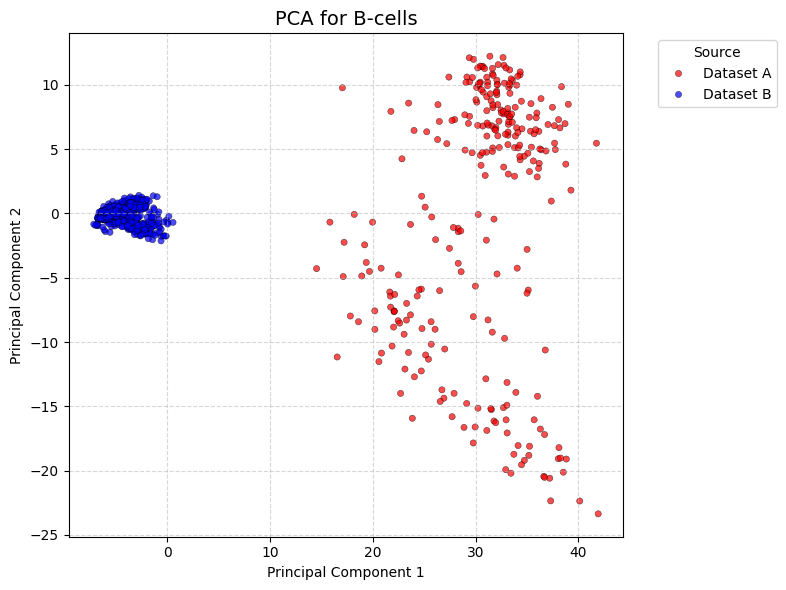

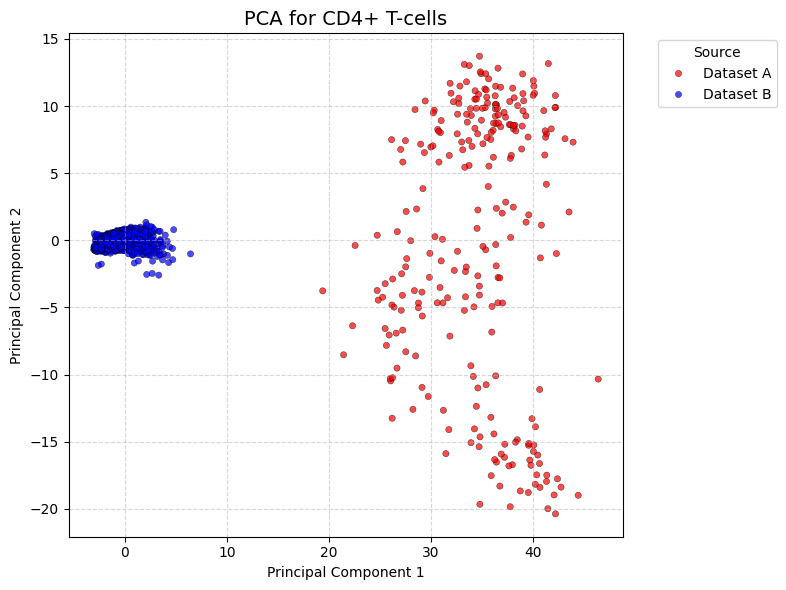

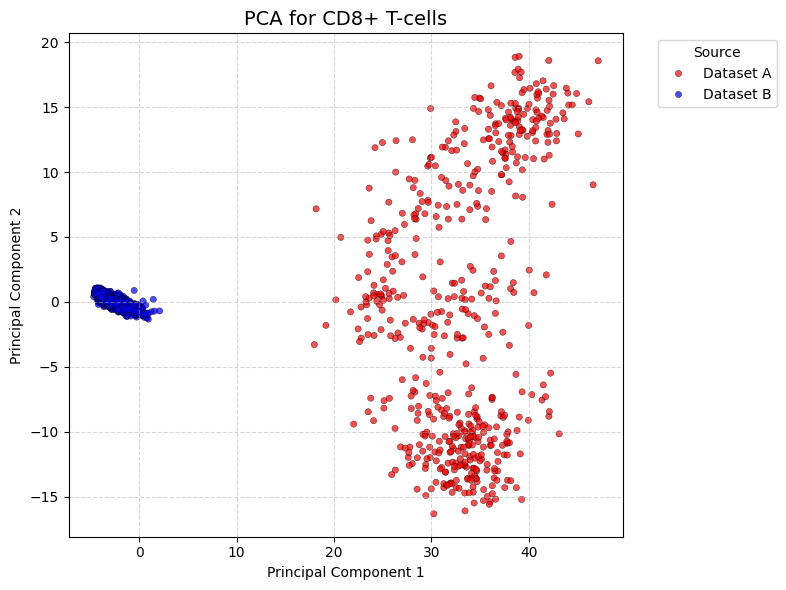

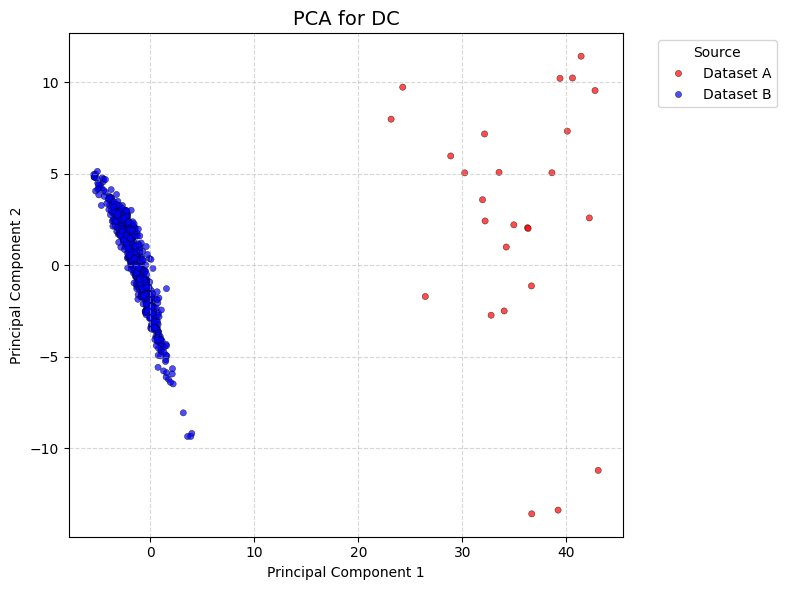

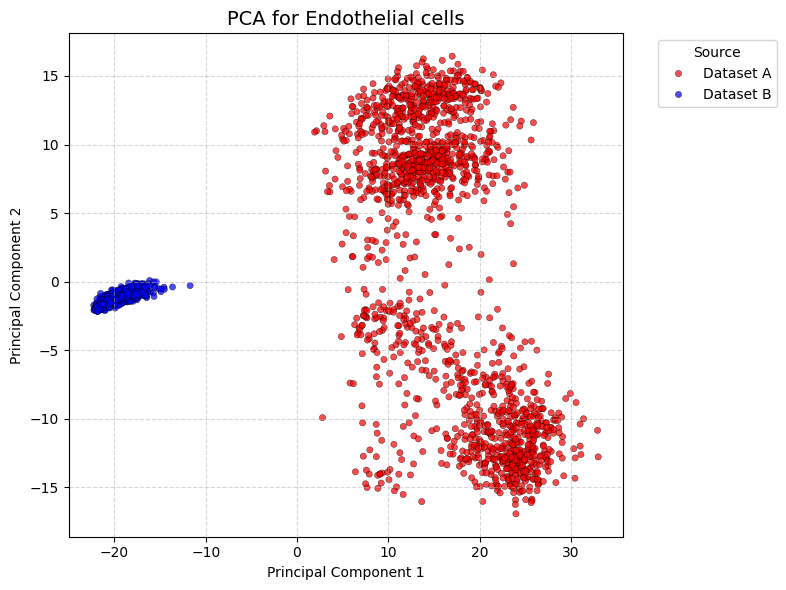

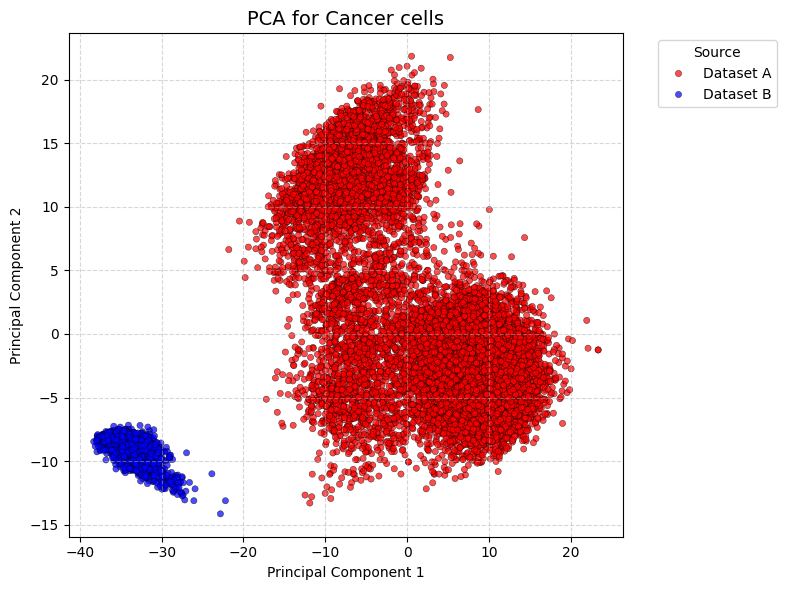

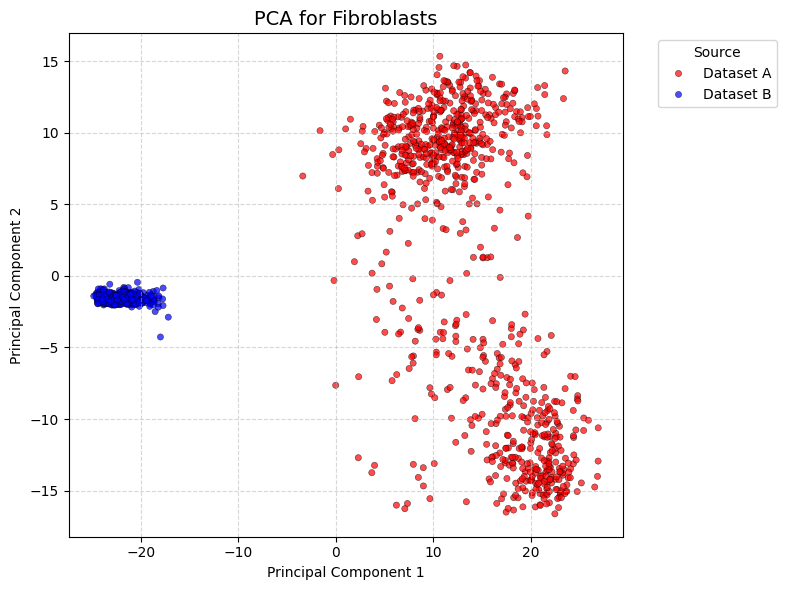

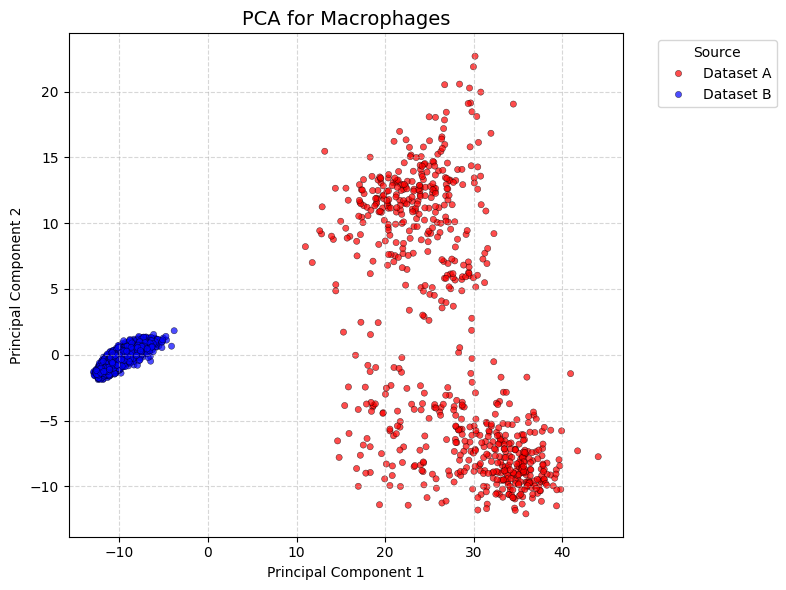

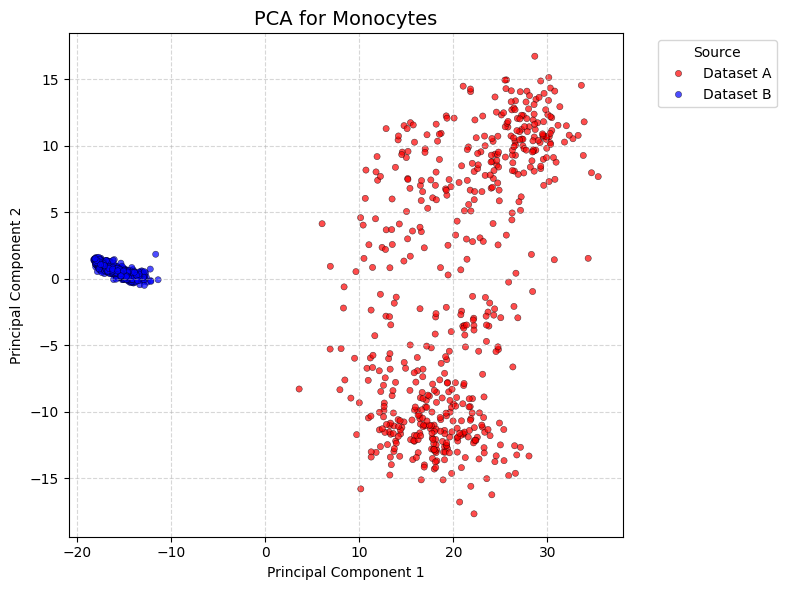

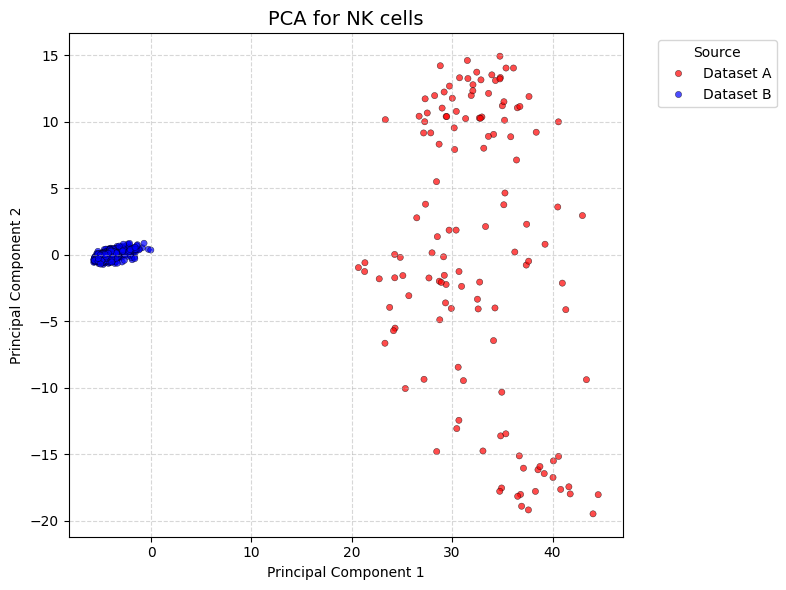

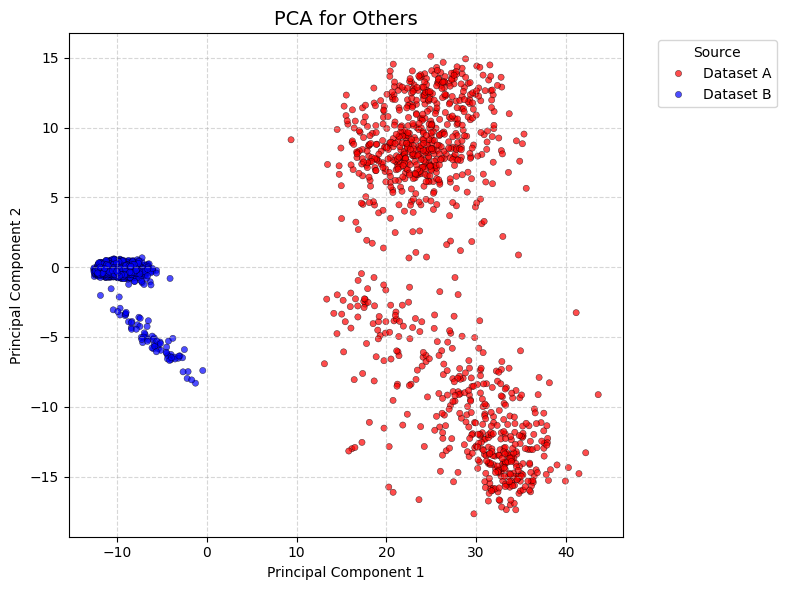

In [14]:
for cell_type in sorted(common_cell_types):
    data_A = reduced_A[reduced_A['cells'] == cell_type].copy()
    data_B = reduced_B[reduced_B['cells'] == cell_type].copy()

    data_A['Source'] = 'Dataset A'
    data_B['Source'] = 'Dataset B'

    combined = pd.concat([data_A, data_B], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    features = combined.drop(columns=['cells', 'Source', 'CellType'])

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(features)

    pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
    pca_df["Source"] = combined["Source"].values

    title = "Cancer cells" if cell_type == "Epithelial cells" else cell_type

    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(
        x="PC1", y="PC2",
        hue="Source",
        palette={"Dataset A": "red", "Dataset B": "blue"},
        data=pca_df,
        alpha=0.7,
        s=20,
        edgecolor="k"
    )

    handles, labels = scatter.get_legend_handles_labels()
    order = ['Dataset A', 'Dataset B']
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: order.index(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_handles_labels)

    plt.title(f"PCA for {title}", fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend(sorted_handles, sorted_labels, title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


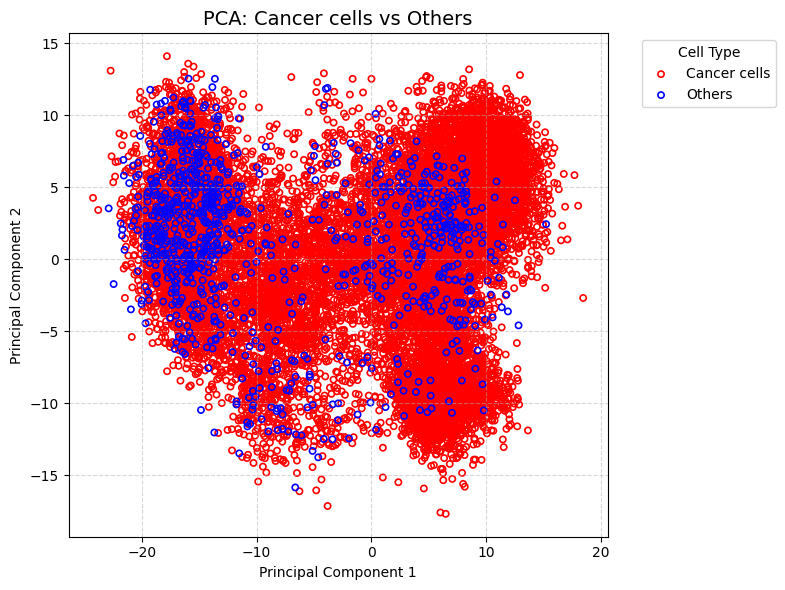

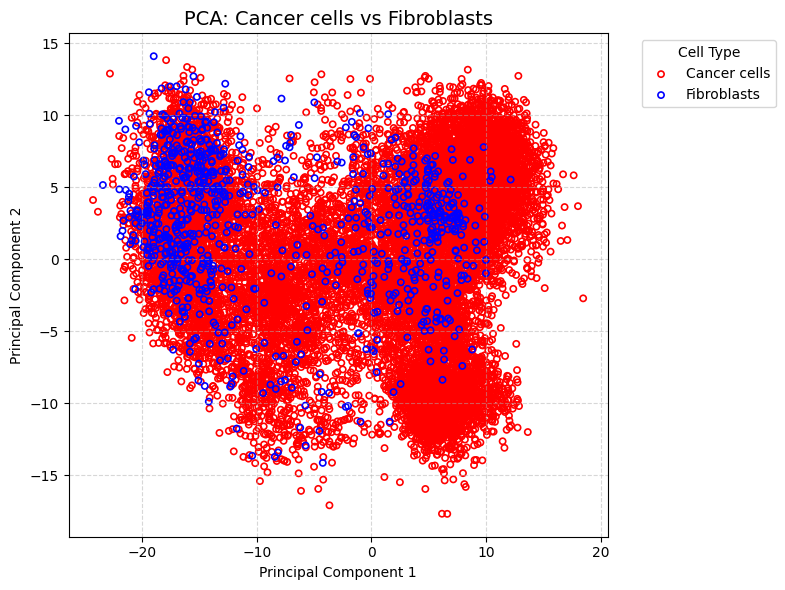

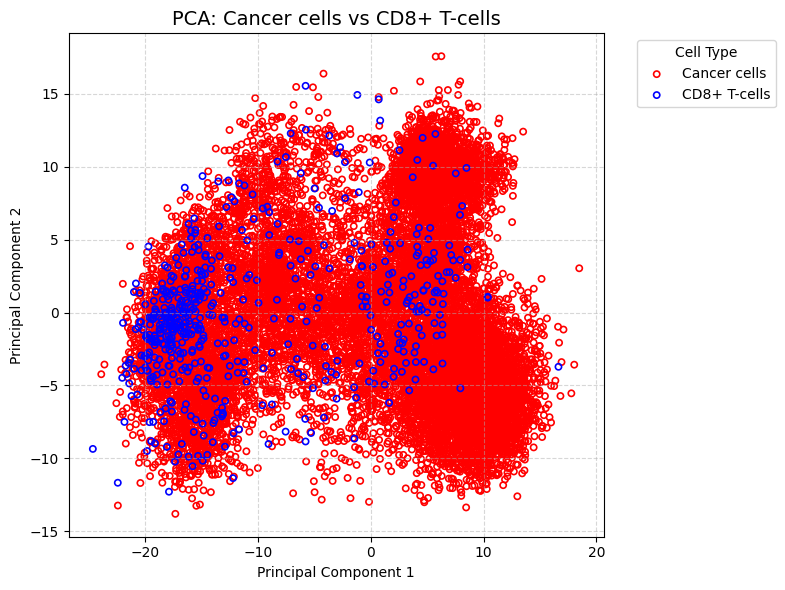

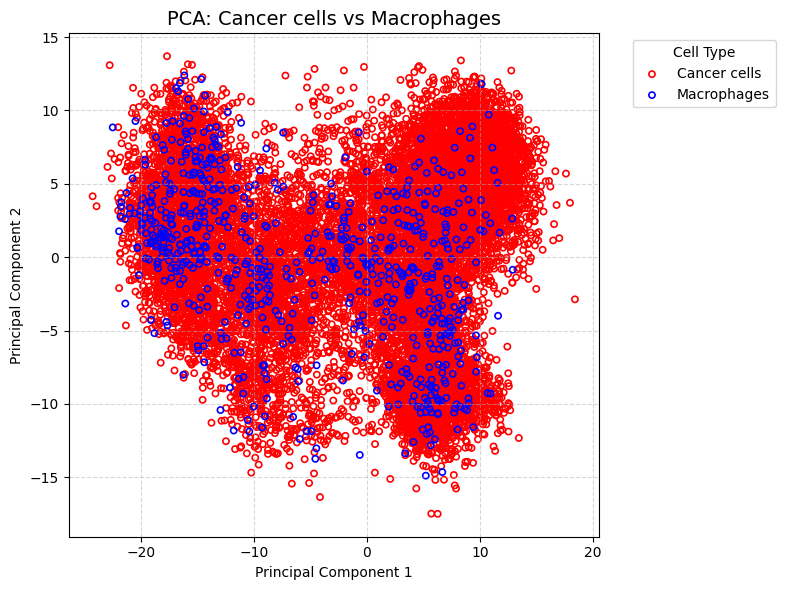

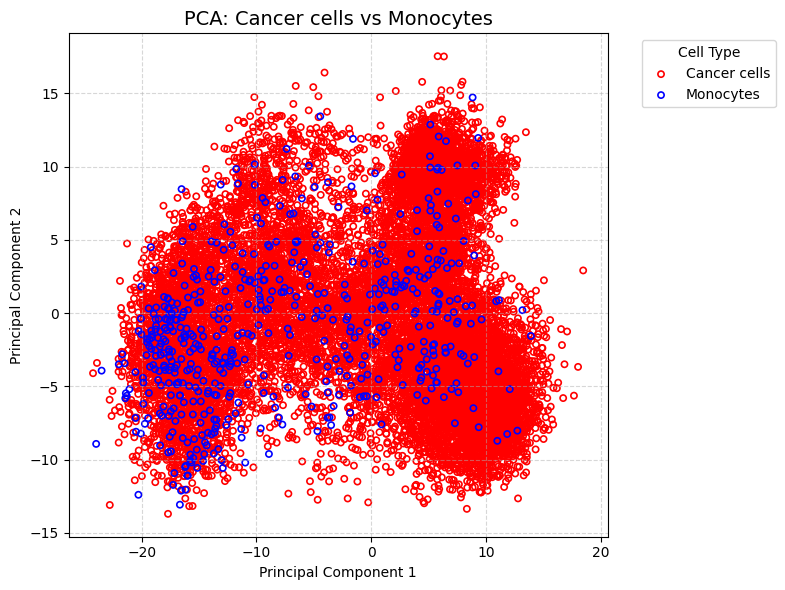

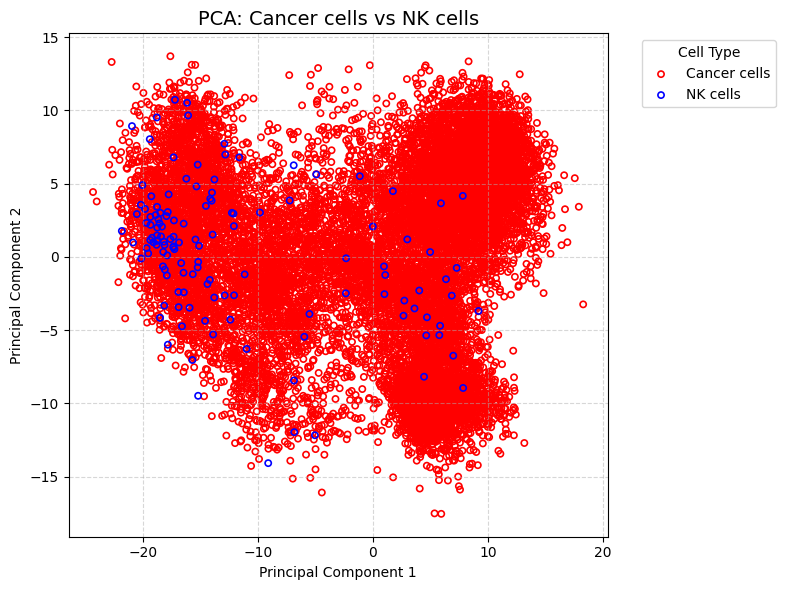

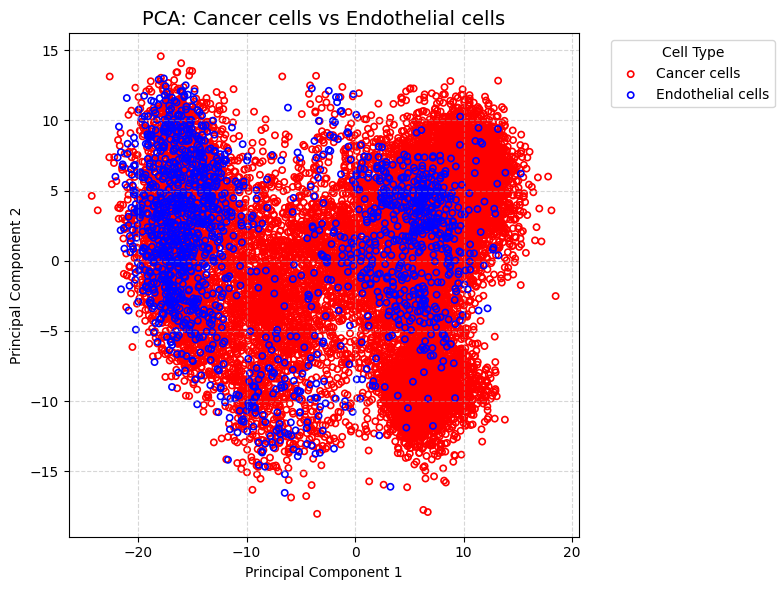

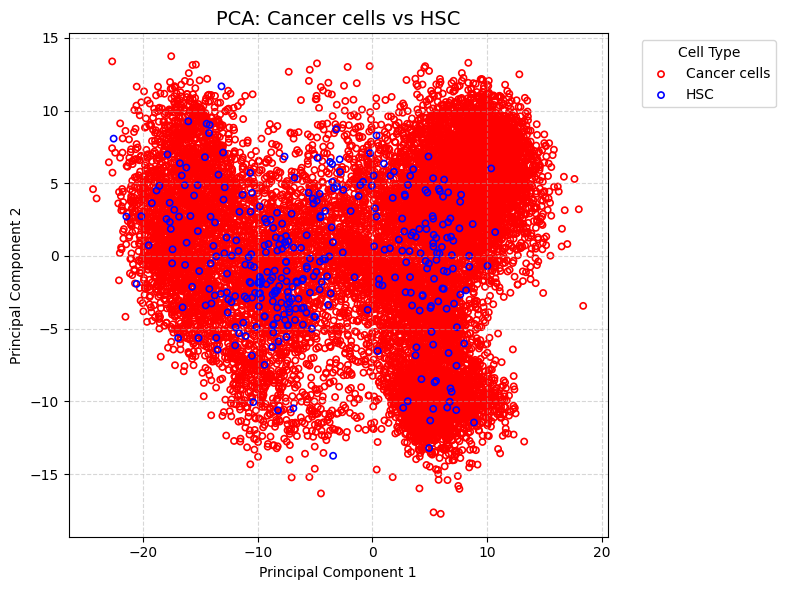

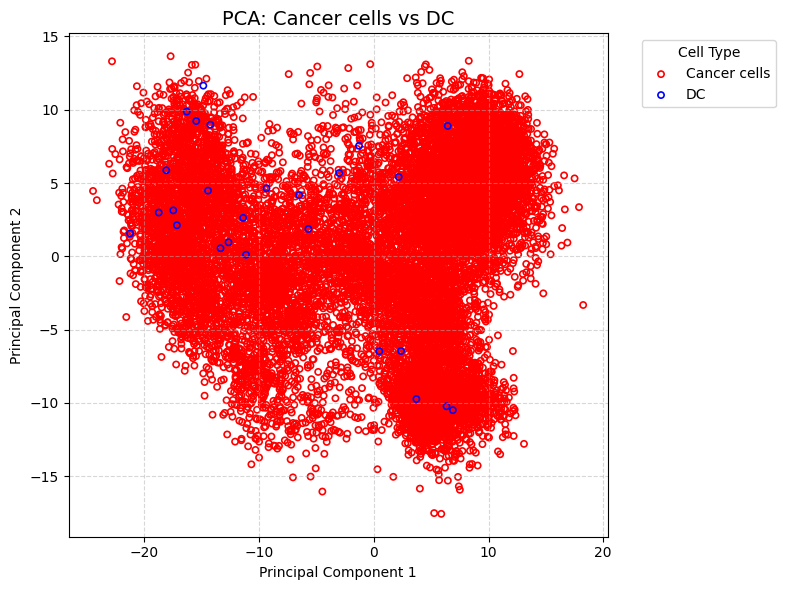

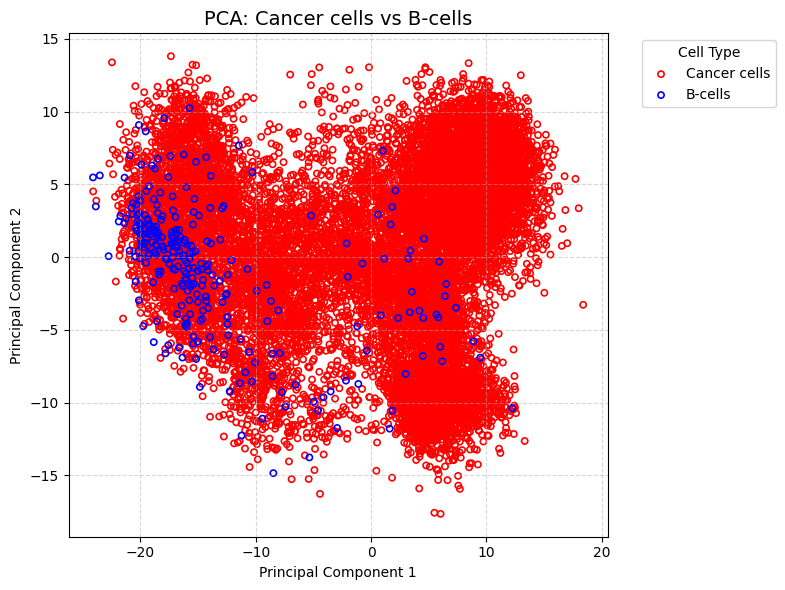

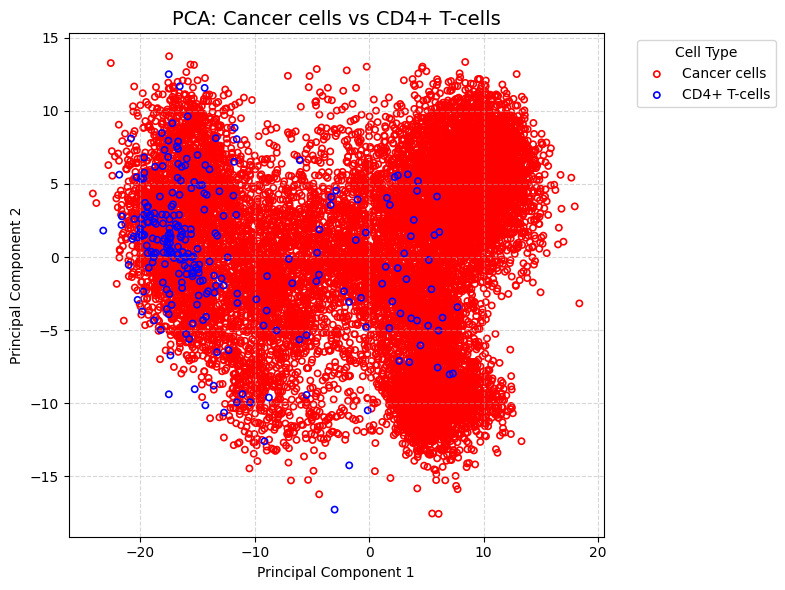

In [21]:
shared_cell_types = reduced_A['cells'].unique()
cell_types_to_plot = [ctype for ctype in shared_cell_types if ctype != "Epithelial cells"]

def plot_pca_epithelial_vs_other(ctype):
    epithelial_A = reduced_A[reduced_A['cells'] == "Epithelial cells"]
    epithelial = pd.DataFrame(epithelial_A)
    epithelial["Group"] = "Cancer cells"

    other_A = reduced_A[reduced_A['cells'] == ctype]
    other = pd.DataFrame(other_A)
    other["Group"] = ctype

    combined = pd.concat([epithelial, other], ignore_index=True)
    combined = shuffle(combined, random_state=42)

    features = combined.drop(columns=["cells", "Group", "CellType"])
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(features)

    pca_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "CellGroup": combined["Group"]
    })

    plt.figure(figsize=(8, 6))
    for group, color in zip(["Cancer cells", ctype], ["red", "blue"]):
      subset = pca_df[pca_df["CellGroup"] == group]
      plt.scatter(
          subset["PC1"],
          subset["PC2"],
          facecolors='none',
          edgecolors=color,
          label=group,
          s=20,
          linewidth=1.2
      )

    plt.title(f"PCA: Cancer cells vs {ctype}", fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

for ctype in cell_types_to_plot:
    plot_pca_epithelial_vs_other(ctype)


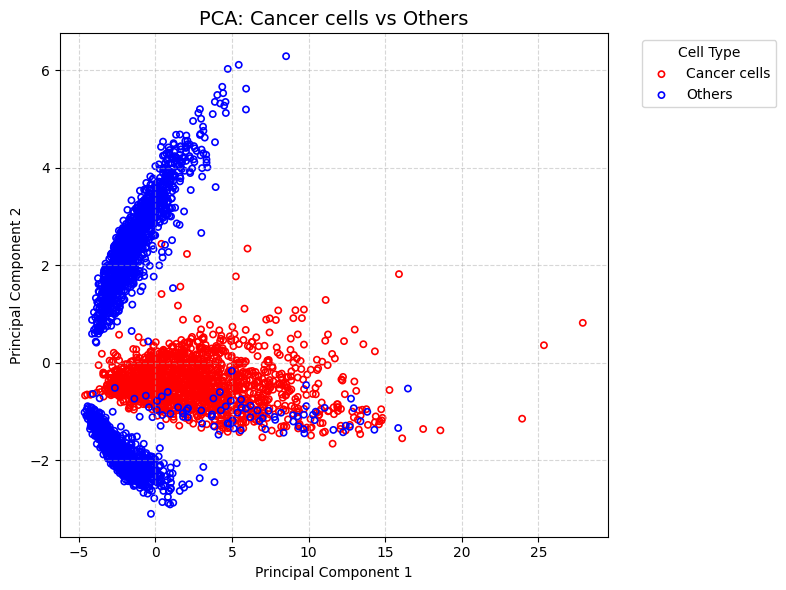

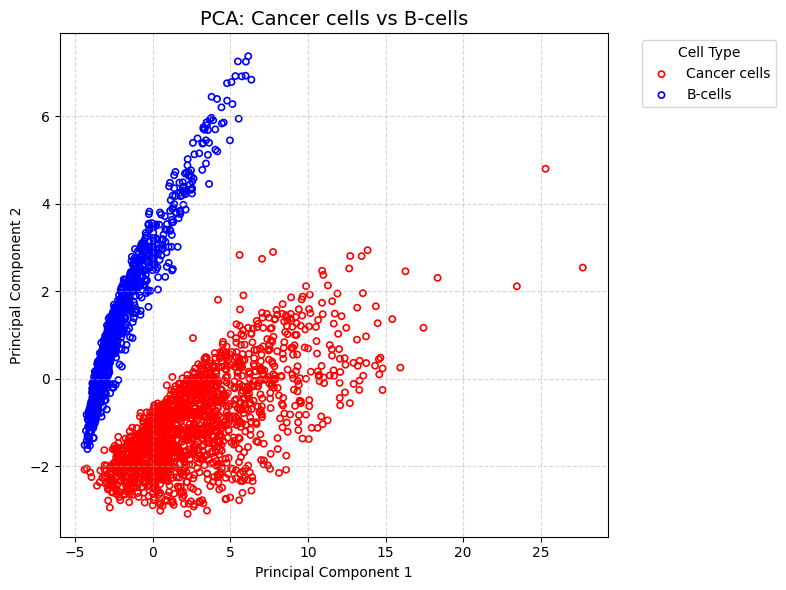

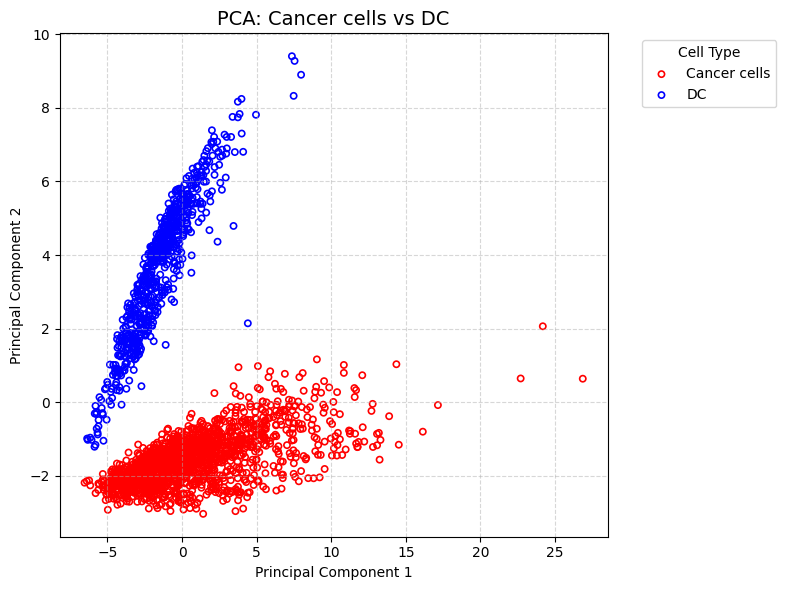

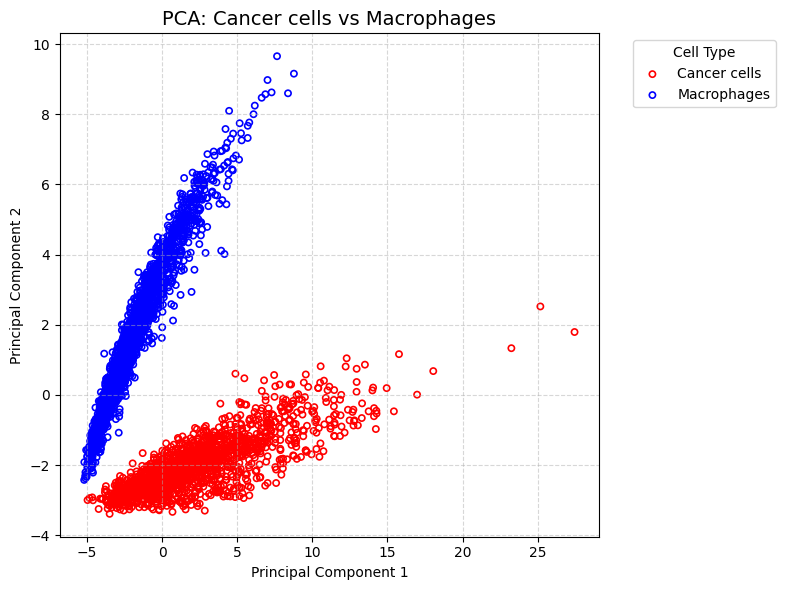

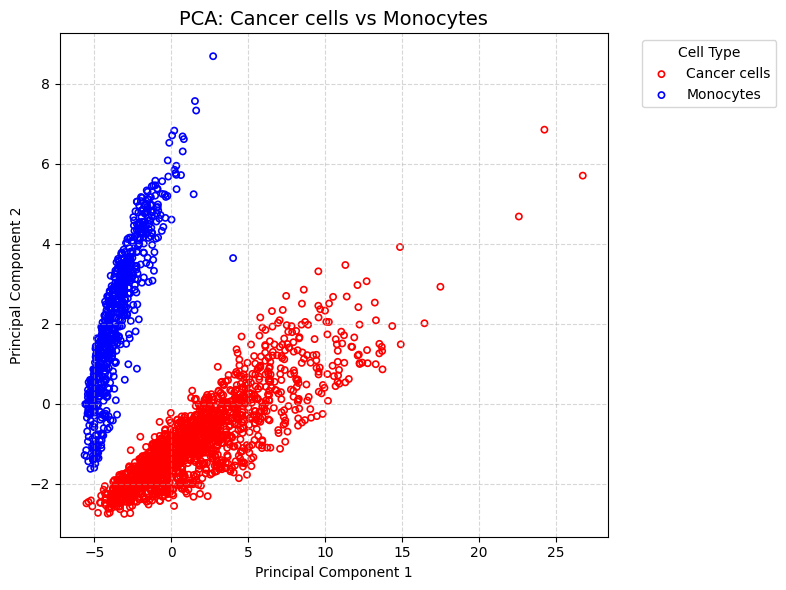

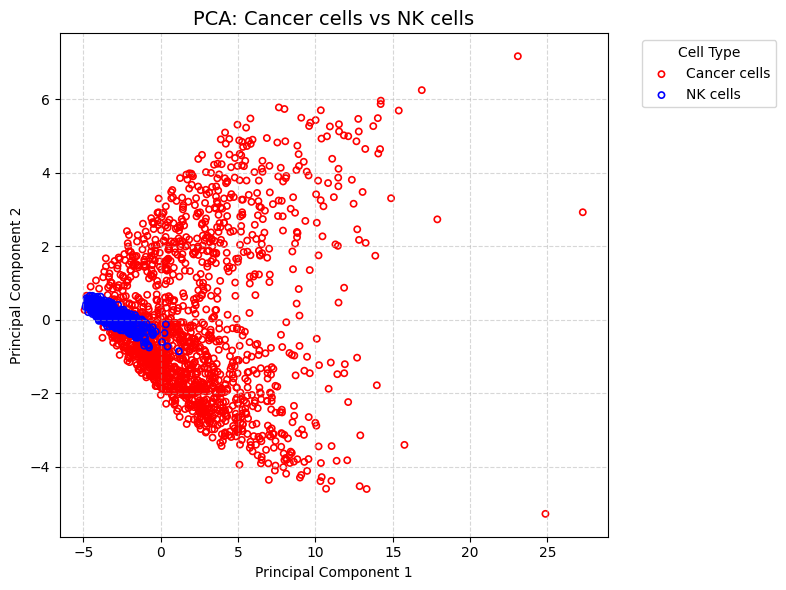

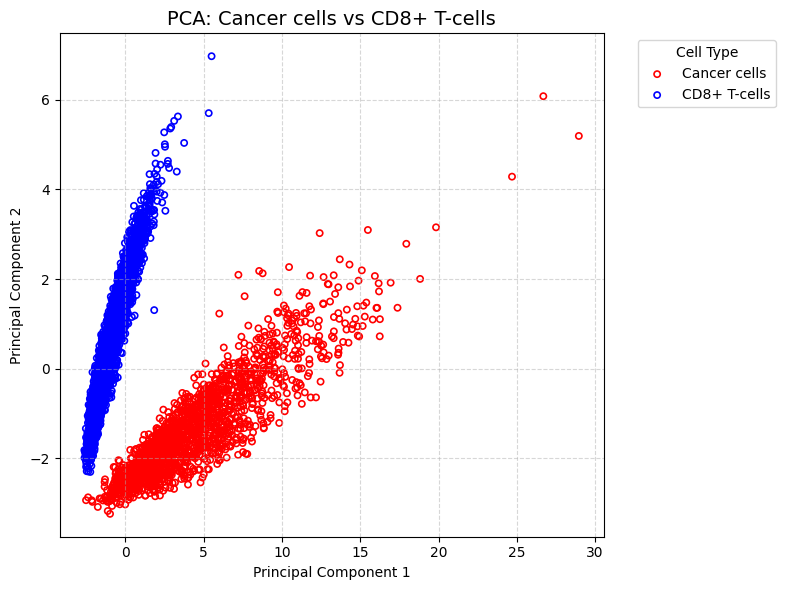

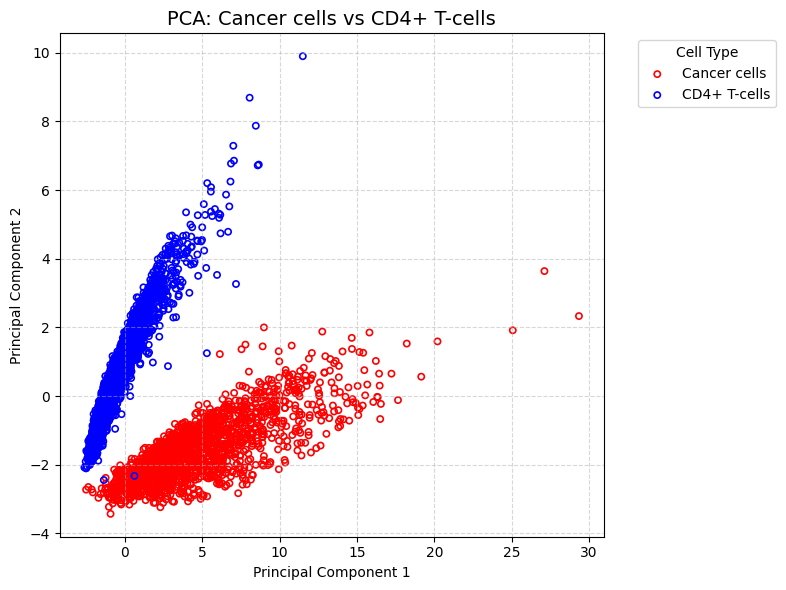

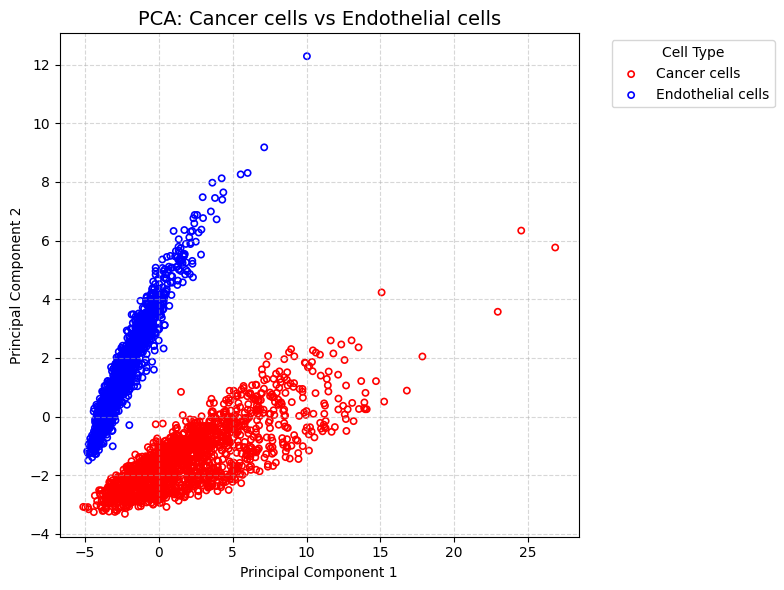

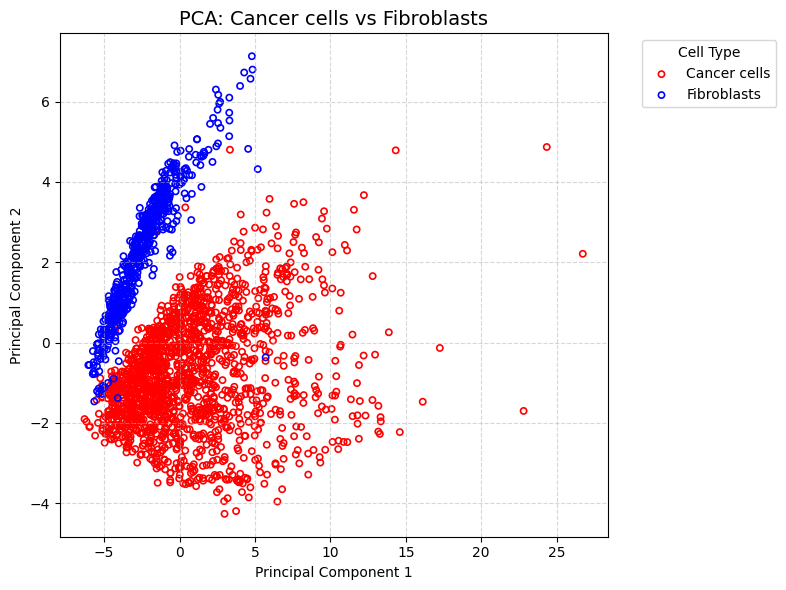

In [22]:
shared_cell_types = reduced_B['cells'].unique()
cell_types_to_plot = [ctype for ctype in shared_cell_types if ctype != "Epithelial cells"]

def plot_pca_epithelial_vs_other(ctype):
    epithelial_B = reduced_B[reduced_B['cells'] == "Epithelial cells"]
    epithelial = pd.DataFrame(epithelial_B)
    epithelial["Group"] = "Cancer cells"

    other_B = reduced_B[reduced_B['cells'] == ctype]
    other = pd.DataFrame(other_B)
    other["Group"] = ctype

    combined = pd.concat([epithelial, other], ignore_index=True)
    combined = shuffle(combined, random_state=42)

    features = combined.drop(columns=["cells", "Group", "CellType"])
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(features)

    pca_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "CellGroup": combined["Group"]
    })

    plt.figure(figsize=(8, 6))
    for group, color in zip(["Cancer cells", ctype], ["red", "blue"]):
      subset = pca_df[pca_df["CellGroup"] == group]
      plt.scatter(
          subset["PC1"],
          subset["PC2"],
          facecolors='none',
          edgecolors=color,
          label=group,
          s=20,
          linewidth=1.2
      )

    plt.title(f"PCA: Cancer cells vs {ctype}", fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

for ctype in cell_types_to_plot:
    plot_pca_epithelial_vs_other(ctype)

Search for Common Features

In [5]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.metrics import precision_score, recall_score, classification_report
import xgboost
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
balanced_A = pd.read_csv("/content/drive/MyDrive/Processed/final/balanced_A.csv")

balanced_A.shape

(28145, 21821)

In [6]:
balanced_B = pd.read_csv("/content/drive/MyDrive/Processed/final/balanced_B.csv")

balanced_B.shape

(10279, 21821)

In [15]:
def experiment(X_train, y_train, X_test, y_test):
    best_xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=9,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss',
        tree_method="hist",
        #device="cuda",
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_lambda=1,
        reg_alpha=0
    )
    best_xgb_model.fit(X_train, y_train)
    best_xgb_model.save_model("xgb_A.json")

    y_pred = best_xgb_model.predict(X_test)
    f1_test = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print("\nFinal Test Set Evaluation Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_test:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
                annot_kws={"size": 14}, linewidths=0.5)

    plt.xticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12)
    plt.yticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12, rotation=0)

    plt.xlabel("Predicted Label", fontsize=13)
    plt.ylabel("True Label", fontsize=13)
    plt.title("Confusion Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()


Final Test Set Evaluation Metrics:
Precision: 0.8570
Recall: 0.8488
F1-Score: 0.8491

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4628
           1       0.79      0.91      0.84      3816

    accuracy                           0.85      8444
   macro avg       0.85      0.85      0.85      8444
weighted avg       0.86      0.85      0.85      8444



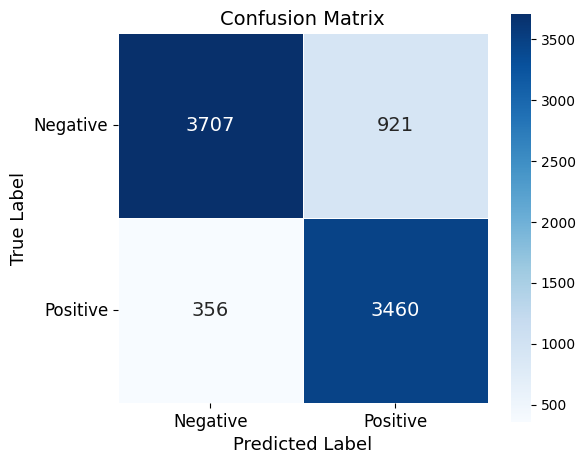

In [16]:
X = balanced_A.iloc[:, 1:-1].values
y = balanced_A['CellType'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

experiment(X_train, y_train, X_test, y_test)

Feature Importance (Trained on Full)

In [22]:
loaded_xgb_model = XGBClassifier()
loaded_xgb_model.load_model("xgb_B.json")

In [23]:
feature_importances = loaded_xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': balanced_B.columns[1:-1],
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df.head()

,Feature,Importance
20234,FXYD3,0.203553
13789,KRT8,0.073219
18157,PRAC1,0.034838
20740,KLK3,0.023202
18828,SLC14A1,0.016370


In [24]:
feature_importance_df.shape

(21819, 2)

In [25]:
feature_importance_df.to_csv("importance_B_all.csv", index=False)

Feature Overlap

In [26]:
importance_A = pd.read_csv("importance_A_all.csv")
importance_B = pd.read_csv("importance_B_all.csv")

importance_A["Rank_A"] = range(1, len(importance_A) + 1)
importance_B["Rank_B"] = range(1, len(importance_B) + 1)

importance_A.rename(columns={"Importance": "Importance_A"}, inplace=True)
importance_B.rename(columns={"Importance": "Importance_B"}, inplace=True)

ranges = [300, 500, 1000, 2000, 3000, 4000, 5000, 10000, 12000, 14000, 16000, 18000, 20000, 21819]

In [27]:
for top_n in ranges:
    top_A = importance_A.head(top_n)
    top_B = importance_B.head(top_n)

    features_A = set(top_A["Feature"])
    features_B = set(top_B["Feature"])

    overlap = features_A & features_B
    overlap_count = len(overlap)
    overlap_percentage = overlap_count / top_n * 100

    print(f"Top {top_n} features → Overlap: {overlap_count} / {top_n} ({overlap_percentage:.2f}%)")

Top 300 features → Overlap: 17 / 300 (5.67%)
Top 500 features → Overlap: 28 / 500 (5.60%)
Top 1000 features → Overlap: 63 / 1000 (6.30%)
Top 2000 features → Overlap: 235 / 2000 (11.75%)
Top 3000 features → Overlap: 476 / 3000 (15.87%)
Top 4000 features → Overlap: 843 / 4000 (21.07%)
Top 5000 features → Overlap: 1311 / 5000 (26.22%)
Top 10000 features → Overlap: 4681 / 10000 (46.81%)
Top 12000 features → Overlap: 7573 / 12000 (63.11%)
Top 14000 features → Overlap: 9952 / 14000 (71.09%)
Top 16000 features → Overlap: 12698 / 16000 (79.36%)
Top 18000 features → Overlap: 14678 / 18000 (81.54%)
Top 20000 features → Overlap: 18396 / 20000 (91.98%)
Top 21819 features → Overlap: 21819 / 21819 (100.00%)


In [28]:
importance_A = pd.read_csv("importance_A_all.csv")
importance_B = pd.read_csv("importance_B_all.csv")

In [31]:
top_A = importance_A.head(500).copy()
top_B = importance_B.head(500).copy()

top_A["Rank_A"] = range(1, len(top_A) + 1)
top_B["Rank_B"] = range(1, len(top_B) + 1)

top_A.rename(columns={"Importance": "Importance_A"}, inplace=True)
top_B.rename(columns={"Importance": "Importance_B"}, inplace=True)

merged_df = pd.merge(top_A, top_B, on="Feature")

result = merged_df[["Feature", "Rank_A", "Rank_B", "Importance_A", "Importance_B"]]

result.to_csv("overlapping_28.csv", index=False)

print(result.head())

   Feature  Rank_A  Rank_B  Importance_A  Importance_B
0    RPL7A       1     447      0.005126      0.000265
1    HLA-B       2     398      0.004963      0.000357
2     PCA3       4     101      0.001988      0.001797
3  C1orf64       8     219      0.001205      0.000961
4    PRAC1       9       3      0.001131      0.034838


In [5]:
df_17 = pd.read_csv("overlapping_17.csv")

df_17

,Feature,Rank_A,Rank_B,Importance_A,Importance_B
0,PCA3,4,101,0.001988,0.001797
1,C1orf64,8,219,0.001205,0.000961
2,PRAC1,9,3,0.001131,0.034838
3,KLK11,13,54,0.000765,0.002763
4,LCN2,34,33,0.000529,0.003516
5,KLK3,45,4,0.000488,0.023202
6,RP11-44F21.5,91,116,0.000409,0.001569
7,AIF1,106,149,0.000394,0.001335
8,PI4KB,119,242,0.000384,0.000869
9,AZGP1,135,38,0.000378,0.003366


In [6]:
df_28 = pd.read_csv("overlapping_28.csv")

df_28

,Feature,Rank_A,Rank_B,Importance_A,Importance_B
0,RPL7A,1,447,0.005126,0.000265
1,HLA-B,2,398,0.004963,0.000357
2,PCA3,4,101,0.001988,0.001797
3,C1orf64,8,219,0.001205,0.000961
4,PRAC1,9,3,0.001131,0.034838
5,KLK11,13,54,0.000765,0.002763
6,LCN2,34,33,0.000529,0.003516
7,TFF3,36,485,0.000519,0.000208
8,KLK3,45,4,0.000488,0.023202
9,DGKA,66,409,0.000443,0.000330


In [7]:
features_17 = set(df_17['Feature'])
df_first = df_28[df_28['Feature'].isin(features_17)].sort_values('Rank_A')

df_remaining = df_28[~df_28['Feature'].isin(features_17)].sort_values('Rank_A')

final_df = pd.concat([df_first, df_remaining], ignore_index=True)

print(final_df)

         Feature  Rank_A  Rank_B  Importance_A  Importance_B
0           PCA3       4     101      0.001988      0.001797
1        C1orf64       8     219      0.001205      0.000961
2          PRAC1       9       3      0.001131      0.034838
3          KLK11      13      54      0.000765      0.002763
4           LCN2      34      33      0.000529      0.003516
5           KLK3      45       4      0.000488      0.023202
6   RP11-44F21.5      91     116      0.000409      0.001569
7           AIF1     106     149      0.000394      0.001335
8          PI4KB     119     242      0.000384      0.000869
9          AZGP1     135      38      0.000378      0.003366
10        GLB1L3     136     162      0.000376      0.001231
11         DOCK8     206     192      0.000343      0.001051
12         KRT19     225      23      0.000333      0.004781
13       FAM198B     239      94      0.000326      0.001911
14          IGF1     242     281      0.000324      0.000708
15           VWF     252

In [71]:
overlap_df = pd.read_csv("overlapping_17.csv")

selected_features = overlap_df["Feature"].tolist()

columns_to_extract = selected_features + ["CellType"]

subset_balanced_B = reduced_B[columns_to_extract]

In [72]:
subset_balanced_B.shape

(28855, 18)

In [73]:
subset_balanced_B.head()

,PCA3,C1orf64,PRAC1,KLK11,LCN2,KLK3,RP11-44F21.5,AIF1,PI4KB,AZGP1,GLB1L3,DOCK8,KRT19,FAM198B,IGF1,VWF,GNLY,CellType
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,non-Epithelial
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.321,0.0,0.0,0.0,0.0,non-Epithelial
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,non-Epithelial
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,non-Epithelial
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,non-Epithelial


In [74]:
subset_balanced_B.to_csv("unbalanced_B_17.csv", index=False)

Dataset C

In [17]:
import scanpy as sc
import pandas as pd

In [18]:
adata = sc.read_h5ad("dge_combined_annotated.h5ad")

expression_df = adata.to_df()

if 'cell_type' in adata.obs.columns:
    expression_df['CellType'] = adata.obs['cell_type']
else:
    print("⚠️ 'cell_type' not found in metadata. Available columns:", adata.obs.columns)

print("✅ Expression data shape:", expression_df.shape)
print(expression_df.head())

⚠️ 'cell_type' not found in metadata. Available columns: Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rps',
       'percent.rpl', 'percent.ribosomal', 'sample', 'RNA_snn_res.3',
       'seurat_clusters', 'BE1', 'Club1', 'Luminal1', 'TMPRSS2ERG1',
       'LIU_PROSTATE1', 'WALLACE_PROSTATE_RACE_UP1', 'TOMLIN_PROSTATE1', 'NE1',
       'Hillock1', 'Endothelial1', 'Fib1', 'SM1', 'B.cell1', 'Leu1',
       'Macrophage1', 'T.cell1', 'Tcell1', 'Bcell1', 'ID', 'all', 'ID_coarse',
       'refinedID'],
      dtype='object')
✅ Expression data shape: (21743, 2000)
                A2M     ABCA1     ABCA6     ABCA8     ABCA9     ABCB1  \
AUG_PB1   -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.1 -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.2 -0.467991  0.905149 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.3 -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.4 -0.467991 -0.245610 -0.081207 -0.138044

/usr/local/lib/python3.11/dist-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [19]:
adata = sc.read_h5ad("dge_combined_annotated.h5ad")

cell_types = adata.obs['refinedID'].copy()

expression_df = pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

expression_df['CellType'] = cell_types

print(expression_df.shape)
print(expression_df.head())

(21743, 2001)
                A2M     ABCA1     ABCA6     ABCA8     ABCA9     ABCB1  \
AUG_PB1   -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.1 -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.2 -0.467991  0.905149 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.3 -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   
AUG_PB1.4 -0.467991 -0.245610 -0.081207 -0.138044 -0.049999 -0.269546   

              ABCC4    ABCC9     ABCG2    ABI3BP  ...  IGLV2-11       RAX  \
AUG_PB1    1.096069 -0.12562 -0.210733 -0.138711  ... -0.014233 -0.022946   
AUG_PB1.1  1.033801 -0.12562 -0.210733 -0.138711  ... -0.014233 -0.022946   
AUG_PB1.2  0.893176 -0.12562 -0.210733  0.594816  ... -0.014233 -0.022946   
AUG_PB1.3  1.002465 -0.12562 -0.210733 -0.138711  ... -0.014233 -0.022946   
AUG_PB1.4  0.746359 -0.12562 -0.210733 -0.138711  ... -0.014233 -0.022946   

           RP11-184M15.1  RP11-973H7.4      AQP2      MMP8     PATE1  \
AUG_PB1     

/usr/local/lib/python3.11/dist-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [62]:
epithelial_keywords = ['Luminal', 'Basal', 'Club', 'Hillock', 'NE', 'BE']

def classify_epithelial(cell_type):
    return "Epithelial" if any(key.lower() in cell_type.lower() for key in epithelial_keywords) else "non-Epithelial"

adata.obs["CellType"] = adata.obs["refinedID"].apply(classify_epithelial)

expression_df = pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)
expression_df["CellType"] = adata.obs["CellType"]


In [23]:
type_mapping = {
    'Luminal': 'Epithelial cells',
    'Basal': 'Epithelial cells',
    'Club': 'Epithelial cells',
    'Hillock': 'Epithelial cells',
    'NE': 'Epithelial cells',
    'BE': 'Epithelial cells',
    'Fib': 'Fibroblasts',
    'Smooth_muscle': 'Fibroblasts',
    'CD8': 'CD8+ T-cells',
    'Macrophage': 'Macrophages',
    'Mono': 'Monocytes',
    'NK': 'NK cells',
    'Endothelial': 'Endothelial cells',
    'HSC': 'HSC',
    'Hematopoietic': 'HSC',
    'DC': 'DC',
    'Dendritic': 'DC',
    'Bcell': 'B-cells',
    'B.cell': 'B-cells',
    'B-cell': 'B-cells',
    'B.': 'B-cells',
    'Plasma': 'B-cells',
    'CD4': 'CD4+ T-cells',
    'T.helper': 'CD4+ T-cells',
    'T.cell': 'CD4+ T-cells',
    'Tcell': 'CD4+ T-cells',
    'Treg': 'CD4+ T-cells',
    'T-cell': 'CD4+ T-cells',
}

def map_cell_type(old_type):
    for keyword, new_type in type_mapping.items():
        if keyword.lower() in old_type.lower():
            return new_type
    return "Others"

adata.obs["CellType"] = adata.obs["refinedID"].apply(map_cell_type)

expression_df = pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)
expression_df["CellType"] = adata.obs["CellType"]

print(expression_df["CellType"].value_counts())


CellType
Others               8475
Epithelial cells     5494
CD8+ T-cells         1713
Monocytes            1472
Endothelial cells    1332
Fibroblasts          1276
Macrophages           981
CD4+ T-cells          688
B-cells               178
NK cells              134
Name: count, dtype: int64


In [63]:
print(expression_df["CellType"].value_counts())

CellType
non-Epithelial    16249
Epithelial         5494
Name: count, dtype: int64


In [64]:
output_folder = "/content/drive/MyDrive/Processed/final"
expression_df.to_csv(f"{output_folder}/unbalanced_C.csv", index=False)

In [71]:
overlap_df = pd.read_csv("overlapping_28.csv")
overlap_features = list(overlap_df["Feature"])

label_col = "CellType"

all_required_features = overlap_features + [label_col] if label_col in expression_df.columns else overlap_features

missing_features = [feat for feat in all_required_features if feat not in expression_df.columns]
present_features = [feat for feat in all_required_features if feat in expression_df.columns]

if missing_features:
    print("❗ Missing features (will be filled with zeros):")
    for f in missing_features:
        print(f"-", f)

subset_df = expression_df[present_features].copy()

for feat in missing_features:
    subset_df[feat] = 0

subset_df = subset_df[overlap_features + ([label_col] if label_col in expression_df.columns else [])]

❗ Missing features (will be filled with zeros):
- RPL7A
- HLA-B
- C1orf64
- PRAC1
- KLK3
- DGKA
- RP11-44F21.5
- PI4KB
- GLB1L3
- DOCK8
- RPS26
- LINC01088
- RPS6KB2
- H2AFJ


In [72]:
subset_df.shape

(21743, 29)

In [73]:
subset_df.head()

,RPL7A,HLA-B,PCA3,C1orf64,PRAC1,KLK11,LCN2,TFF3,KLK3,DGKA,...,IGF1,VWF,RPS26,GNLY,LINC01088,RPS6KB2,CXCR4,TSPAN8,H2AFJ,CellType
AUG_PB1,0,0,-0.277184,0,0,-0.324619,-0.207231,2.667167,0,0,...,-0.217762,0.614209,0,-0.131604,0,0,-0.492949,1.561856,0,non-Epithelial
AUG_PB1.1,0,0,-0.277184,0,0,-0.324619,-0.207231,-0.242382,0,0,...,-0.217762,-0.272472,0,-0.131604,0,0,-0.492949,0.696661,0,non-Epithelial
AUG_PB1.2,0,0,-0.277184,0,0,1.863326,-0.207231,-0.242382,0,0,...,-0.217762,-0.272472,0,-0.131604,0,0,-0.492949,1.070534,0,non-Epithelial
AUG_PB1.3,0,0,-0.277184,0,0,0.086407,-0.207231,-0.242382,0,0,...,-0.217762,0.002981,0,-0.131604,0,0,-0.492949,1.091081,0,non-Epithelial
AUG_PB1.4,0,0,-0.277184,0,0,-0.324619,-0.207231,1.442019,0,0,...,-0.217762,0.115968,0,-0.131604,0,0,-0.492949,0.834757,0,non-Epithelial


In [74]:
subset_df.to_csv("unbalanced_C_28.csv", index=False)

Train on Balanced

In [25]:
balanced_A_28 = pd.read_csv("balanced_A_28.csv")

balanced_A_28.shape

(28145, 29)

In [26]:
balanced_B_28 = pd.read_csv("balanced_B_28.csv")

balanced_B_28.shape

(10279, 29)

In [30]:
def experiment(X_train, y_train, X_test, y_test):
  param_grid = {
    'n_estimators': [300, 400, 500],
    'max_depth': [7, 9, 11],
    'learning_rate': [0.05, 0.1],
  }

  xgb_model = XGBClassifier(
      random_state=42,
      eval_metric='logloss',
      tree_method="hist",
      #device="cuda" ,
      subsample=0.8,
      colsample_bytree=0.8,
      gamma=0,
      reg_lambda=1,
      reg_alpha=0
  )

  cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

  scorer = make_scorer(f1_score, average='weighted')

  grid_search = GridSearchCV(
      estimator=xgb_model,
      param_grid=param_grid,
      scoring=scorer,
      cv=cv,
      n_jobs=1,
      verbose=1
  )

  grid_search.fit(X_train, y_train)

  best_params = grid_search.best_params_
  print("Best Parameters:", best_params)

  best_xgb_model = XGBClassifier(
      **best_params,
      random_state=42,
      eval_metric='logloss',
      tree_method="hist",
      #device="cuda" ,
      subsample=0.8,
      colsample_bytree=0.8,
      gamma=0,
      reg_lambda=1,
      reg_alpha=0
  )
  best_xgb_model.fit(X_train, y_train)

  best_xgb_model.save_model("xgb_B_28.json")

  y_pred = best_xgb_model.predict(X_test)
  f1_test = f1_score(y_test, y_pred, average='weighted')
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')

  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-Score: {f1_test:.4f}")

  print("\nDetailed Classification Report:")
  print(classification_report(y_test, y_pred))

  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
              annot_kws={"size": 14}, linewidths=0.5)

  plt.xticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12)
  plt.yticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12, rotation=0)

  plt.xlabel("Predicted Label", fontsize=13)
  plt.ylabel("True Label", fontsize=13)
  plt.title("Confusion Matrix", fontsize=14)
  plt.tight_layout()
  plt.show()

Fitting 10 folds for each of 18 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 500}
Precision: 0.9916
Recall: 0.9916
F1-Score: 0.9916

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       1.00      0.99      0.99      1635

    accuracy                           0.99      3084
   macro avg       0.99      0.99      0.99      3084
weighted avg       0.99      0.99      0.99      3084



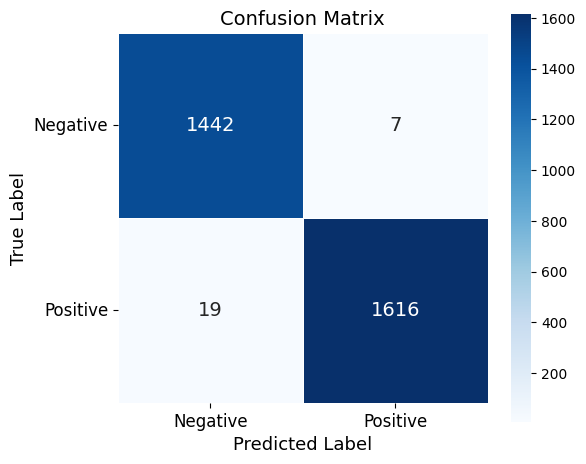

In [31]:
X = balanced_B_28.iloc[:, :-1].values
y = balanced_B_28['CellType'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

experiment(X_train, y_train, X_test, y_test)

Test (Balanced)

In [114]:
loaded_xgb_model2 = XGBClassifier()
loaded_xgb_model2.load_model("xgb_B_28.json")

In [115]:
train = pd.read_csv("balanced_B_28.csv")

train.shape

(10279, 29)

In [122]:
test = pd.read_csv("unbalanced_C_28.csv")

test.shape

(21743, 29)

In [123]:
X = test.iloc[:, :-1]
y_test = test['CellType']
y_train = train['CellType']

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

🔹 Precision: 0.8137
🔹 Recall: 0.5526
🔹 F1 Score: 0.5656

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.96      0.52      5494
           1       0.97      0.42      0.58     16249

    accuracy                           0.55     21743
   macro avg       0.66      0.69      0.55     21743
weighted avg       0.81      0.55      0.57     21743



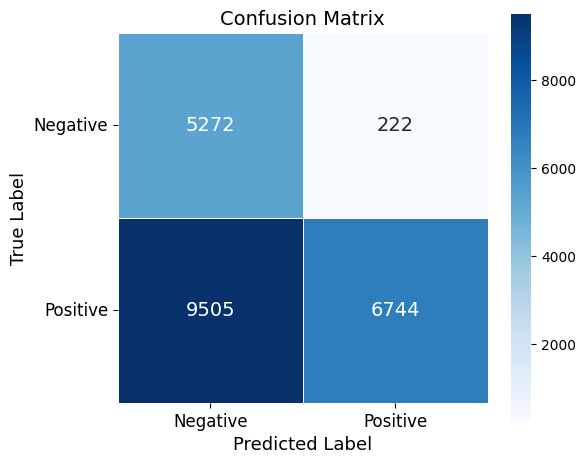

In [124]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_pred = loaded_xgb_model2.predict(X)

f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall: {recall:.4f}")
print(f"🔹 F1 Score: {f1:.4f}")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True,
            annot_kws={"size": 14}, linewidths=0.5)

plt.xticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12)
plt.yticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], fontsize=12, rotation=0)

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
import sys
import importlib

print(f"Python version: {sys.version}\n")
print("Imported library versions:\n")

alias_map = {
    'np': 'numpy',
    'pd': 'pandas',
    'plt': 'matplotlib',
    'sns': 'seaborn',
    'PCA': 'sklearn',
    'shuffle': 'sklearn',
    'xgboost': 'xgboost',
    'sklearn': 'sklearn',
    'sc': 'scanpy',
    'sns': 'seaborn'

}

seen = set()
for alias, module_name in alias_map.items():
    if module_name not in seen:
        try:
            mod = importlib.import_module(module_name)
            version = mod.__version__
            print(f"{module_name}: {version}")
            seen.add(module_name)
        except Exception as e:
            print(f"{module_name}: ❌ ({e})")


Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]

Imported library versions:

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
sklearn: 1.6.1
xgboost: 2.1.4
scanpy: 1.11.1
